# EDA: 565 markets from 565 event families

This notebook uses the final `20260916_v2` sample: **200 Sports, 200 Politics and 165 Economics markets**, with **155,177 trade records** and **75,061 hourly price observations**. Every analysis and saved output below uses these tables.

The setup fixes the input directory, checks file hashes and verifies the row counts. It does not select data through an environment variable or a previously imported loader. Run all cells from the project checkout to reproduce the results.

**Figure code lives here.** All ten website charts are implemented in the tagged cells. Source IDs 01, 02, 06, 03, 04, 05, 07, 08, 11 and 12 correspond to website Figures 01 through 10. Additional cells examine concentration, repeated-row sensitivity and preliminary forecast distributions using the same sample. Sports is blue (`#276FBF`), Politics orange (`#C76D25`) and Economics teal (`#148477`).

**Figure 01 also needs the original discovery pool and 600-market draw** to calculate the requested pool, replacement and final-count comparison. These inputs describe sample selection; they do not supply trades, prices or forecasts to the other analyses.

Trades cover up to seven days ending 24 hours before the event boundary, shortened when listing occurred later. A zero-trade window does not establish that a market never traded. Price paths use the first outcome token, whose label is not always Yes. Account activity sums returned records and is not reconciled exchange turnover.

See `data/eda/20260916_v2/data_dictionary.md` for field definitions. The forecast plots are descriptive, with no fitted model or model-specific normalization.


In [1]:
from pathlib import Path
import json, hashlib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'data/eda/20260916_v2/manifest.json').is_file())
DATA_VERSION = '20260916_v2'
DATA = ROOT / 'data/eda' / DATA_VERSION
FIGURES = ROOT / 'figures/eda_20260916_v2'
EXPECTED_ROWS = {'markets': 565, 'trades': 155177, 'price_history': 75061}
EXPECTED_TOPICS = {'Sports': 200, 'Politics': 200, 'Economics': 165}


def load_table(name, *, exact_signature_sensitivity=False, columns=None):
    """Load only this notebook's frozen tables, preserving typed identifiers."""
    if name not in EXPECTED_ROWS:
        raise ValueError('Unknown current-sample table: ' + name)
    if exact_signature_sensitivity and name != 'trades':
        raise ValueError('The exact-signature view applies only to trades')
    requested = list(columns) if columns is not None else None
    loaded = None if requested is None else list(requested)
    if loaded is not None and 'market_id' not in loaded:
        loaded.append('market_id')
    if exact_signature_sensitivity and loaded is not None and 'in_exact_signature_sensitivity' not in loaded:
        loaded.append('in_exact_signature_sensitivity')
    frame = pd.read_parquet(DATA / f'{name}.parquet', columns=loaded, dtype_backend='pyarrow')
    assert len(frame) == EXPECTED_ROWS[name], f'Unexpected {name} row count'
    if name != 'markets':
        assert set(frame.market_id).issubset(set(markets.market_id)), 'Unexpected market IDs'
    if exact_signature_sensitivity:
        frame = frame[frame.in_exact_signature_sensitivity].copy()
    return frame if requested is None else frame[requested]


validation=json.loads((DATA/'validation.json').read_text())
assert validation['all_checks_pass']
manifest=json.loads((DATA/'manifest.json').read_text())
for name,digest in manifest['output_sha256'].items():
    assert hashlib.sha256((DATA/name).read_bytes()).hexdigest()==digest, name
markets=load_table('markets')
assert markets.market_id.nunique() == markets.event_family_id.nunique() == 565
assert markets.groupby('topic').size().to_dict() == EXPECTED_TOPICS
prices=load_table('price_history')
TOPICS=['Sports','Politics','Economics']
COLORS={'Sports':'#276FBF','Politics':'#C76D25','Economics':'#148477'}
FIGURES.mkdir(parents=True,exist_ok=True)
(FIGURES/'chart_data').mkdir(exist_ok=True)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.titlesize':14,
    'axes.titleweight':'bold','axes.labelsize':10,'axes.spines.top':False,'axes.spines.right':False,
    'figure.facecolor':'white','axes.facecolor':'white','savefig.facecolor':'white','svg.fonttype':'none'})
visuals=[]

def ecdf(ax,values,**kwargs):
    values=np.sort(np.asarray(values,dtype=float))
    if len(values):ax.step(values,np.arange(1,len(values)+1)/len(values),where='post',**kwargs)

def save(fig,stem,title,caption,data,source,footer):
    # Interpretation notes stay in captions and metadata, outside the image.
    fig.tight_layout()
    fig.savefig(FIGURES/f'{stem}.png',dpi=180)
    fig.savefig(FIGURES/f'{stem}.svg')
    data.to_csv(FIGURES/'chart_data'/f'{stem}.csv',index=False)
    visuals.append(dict(id=stem,title=title,caption=caption,source=source,footer=footer,
        png=f'{stem}.png',svg=f'{stem}.svg',data=f'chart_data/{stem}.csv'))
    display(fig)
    plt.close(fig)

display(pd.DataFrame({'table':['markets','trades','price_history'],
    'rows':[len(markets),int(markets.trade_row_count.sum()),len(prices)], 'grain':['one audited contract and event family','one returned account record','one observed first-token price']}))
display(markets.groupby('topic',sort=False)[['trade_row_count','price_point_count','zero_returned_trades','short_window']].sum())

,table,rows,grain
0,markets,565,one audited contract and event family
1,trades,155177,one returned account record
2,price_history,75061,one observed first-token price


,trade_row_count,price_point_count,zero_returned_trades,short_window
topic,,,,
Politics,48222,30306,2,25
Economics,87685,25945,1,12
Sports,19270,18810,64,157


## 1. Sample composition and retained observations

The final sample contains 565 markets from 565 reviewed event families. Figure 01 compares the discovery pools and original draw with this final sample. Replacement counts identify original selections absent from the final roster, once per market.

Same-month reserves were preferred, followed by nearby months. The final sample is not balanced by month. Original inclusion probabilities are not final-sample weights; sampling months and reviewed event dates remain separate fields.


[
  {
    "topic": "Sports",
    "discovered_pool": 144785,
    "screened_event_groups": 58461,
    "initial_draw": 200,
    "original_retained": 198,
    "replacements_needed": 2,
    "replacements_retained": 2,
    "unfilled_slots": 0,
    "final_cohort": 200
  },
  {
    "topic": "Politics",
    "discovered_pool": 30938,
    "screened_event_groups": 855,
    "initial_draw": 200,
    "original_retained": 89,
    "replacements_needed": 111,
    "replacements_retained": 111,
    "unfilled_slots": 0,
    "final_cohort": 200
  },
  {
    "topic": "Economics",
    "discovered_pool": 3966,
    "screened_event_groups": 276,
    "initial_draw": 200,
    "original_retained": 129,
    "replacements_needed": 71,
    "replacements_retained": 36,
    "unfilled_slots": 35,
    "final_cohort": 165
  }
]


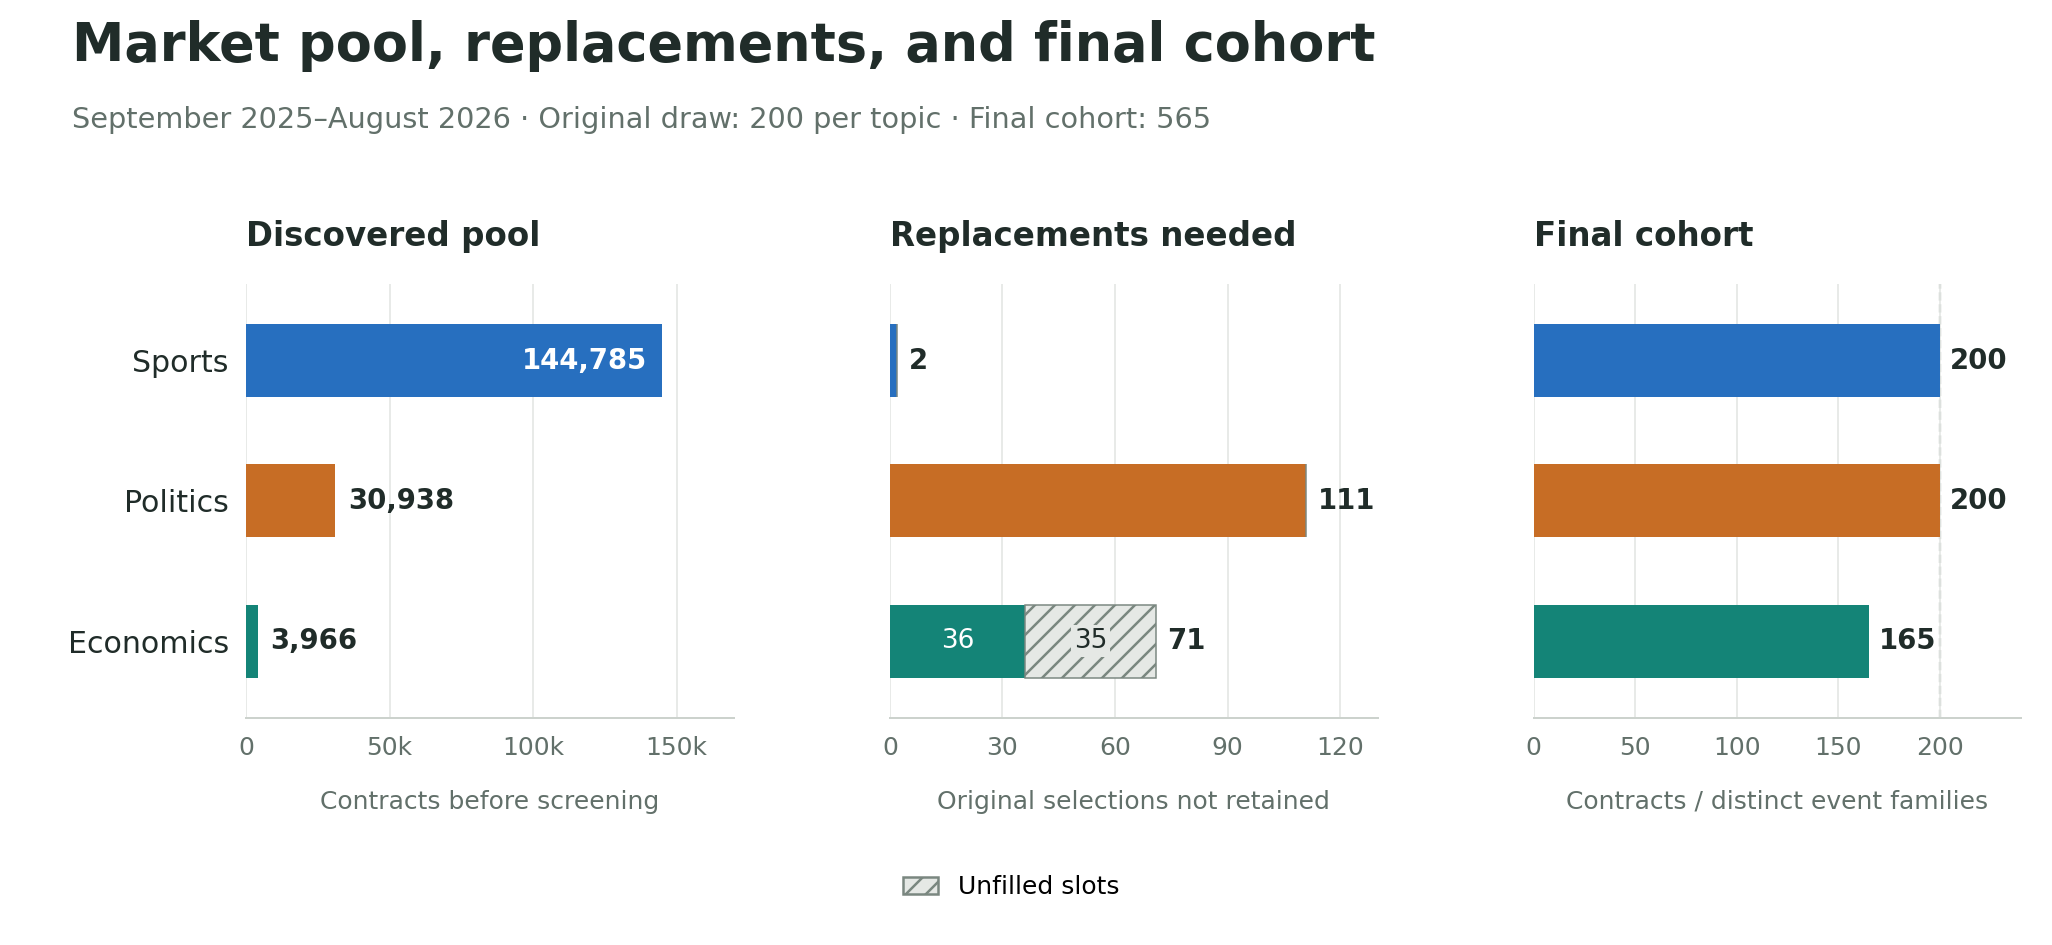

In [2]:
# Website source figure 01: complete calculations and rendering code.
def render_website_figure_01():
    """Reconcile the original draw with the current cohort and render website Figure 01.

    Replacement need counts original identities absent from the final roster once.
    It does not count repeated ledger attempts or intermediate reserve substitutions.
    Run from the project checkout: python -X utf8 -B src/render_sample_flow.py
    """
    import csv
    import hashlib
    import json
    from collections import Counter
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.ticker import FuncFormatter

    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    BASE = ROOT / 'data/cohort_audit/20260914_sample200'
    INVENTORY = ROOT / 'data/cohort_audit/20260914_inventory'
    OUTPUT = ROOT / 'figures/eda_20260917_sample_flow'
    TOPICS = ['Sports', 'Politics', 'Economics']
    COLORS = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    STEM = '01_sample_composition'
    CAPTION = (
        'The discovered pools include 144,785 Sports, 30,938 Politics and 3,966 Economics '
        'contracts before preliminary screening. From the original draw of 200 per topic, '
        '2 Sports, 111 Politics and 71 Economics selections did not remain after the audits '
        'and event-family review. The final cohort contains 200 Sports, 200 Politics and '
        '165 Economics contracts; 35 Economics target slots remained unfilled after the '
        'screened reserve was exhausted. Replacement counts compare the original and final '
        'rosters and do not count repeated candidate attempts.'
    )
    ALT = ('Market selection by topic. Sports: pool 144785, initial 200, replacements '
           'needed 2, filled 2, final 200. Politics: pool 30938, initial 200, replacements '
           'needed 111, filled 111, final 200. Economics: pool 3966, initial 200, '
           'replacements needed 71, filled 36, unfilled 35, final 165.')


    def read_csv(path):
        with path.open(encoding='utf-8-sig', newline='') as handle:
            return list(csv.DictReader(handle))


    def reconcile():
        sources = [INVENTORY / 'candidate_inventory.csv', INVENTORY / 'deferred_mentions.csv',
                   BASE / 'primary_candidates.csv', BASE / 'active_candidates.csv',
                   BASE / 'selection_summary.json', BASE / 'cohort_membership.json',
                   ROOT / 'data/eda/20260916_v2/markets.csv']
        pool = {topic: set() for topic in TOPICS}
        for path in sources[:2]:
            with path.open(encoding='utf-8-sig', newline='') as handle:
                for row in csv.DictReader(handle):
                    assert '2025-09-01' <= row['end_date'][:10] < '2026-09-01'
                    pool[row['topic']].add(row['market_id'])
        original = read_csv(sources[2])
        current = read_csv(sources[3])
        summary = json.loads(sources[4].read_text(encoding='utf-8'))
        membership = json.loads(sources[5].read_text(encoding='utf-8'))
        typed = read_csv(sources[6])
        assert len(original) == len({r['market_id'] for r in original}) == 600
        current_ids = {r['market_id'] for r in current}
        assert len(current) == len(current_ids) == 565
        assert current_ids == set(membership['active_market_ids']) == {r['market_id'] for r in typed}
        assert len({r['event_family_id'] for r in typed}) == 565
        rows, identity_audit = [], []
        for topic in TOPICS:
            initial_ids = {r['market_id'] for r in original if r['topic'] == topic}
            final_ids = {r['market_id'] for r in current if r['topic'] == topic}
            kept = initial_ids & final_ids
            removed = initial_ids - final_ids
            added = final_ids - initial_ids
            assert initial_ids <= pool[topic]
            assert final_ids <= pool[topic]
            row = dict(topic=topic, discovered_pool=len(pool[topic]),
                       screened_event_groups=summary['topics'][topic]['eligible_event_groups'],
                       initial_draw=len(initial_ids), original_retained=len(kept),
                       replacements_needed=len(removed), replacements_retained=len(added),
                       unfilled_slots=len(initial_ids)-len(final_ids), final_cohort=len(final_ids))
            assert row['initial_draw'] == row['original_retained'] + row['replacements_needed'] == 200
            assert row['final_cohort'] == row['original_retained'] + row['replacements_retained']
            assert row['replacements_needed'] == row['replacements_retained'] + row['unfilled_slots']
            assert row['final_cohort'] == membership['topic_counts'][topic]
            assert row['final_cohort'] == Counter(r['topic'] for r in typed)[topic]
            rows.append(row)
            for market_id in sorted(initial_ids | final_ids, key=int):
                identity_audit.append(dict(topic=topic, market_id=market_id,
                                           in_original_draw=market_id in initial_ids,
                                           in_final_cohort=market_id in final_ids,
                                           status=('original_retained' if market_id in kept else
                                                   'original_not_retained' if market_id in removed else
                                                   'reserve_in_final_cohort')))
        receipt = dict(
            definitions={
                'discovered_pool': 'Distinct market IDs per topic in the original scheduled-end-date inventory, including deferred mentions; before preliminary screening. Sports uses the moneyline query. Topic pools overlap.',
                'screened_event_groups': 'Connected API event-ID groups in the preliminary sampling frame; these are not fully audited real-world event families.',
                'replacements_needed': 'Original draw IDs absent from the final same-topic roster, counted once per identity. Includes scope/evidence omissions and family-overlap removals.',
                'replacements_retained': 'Final roster IDs absent from the original same-topic draw. Intermediate replacements later removed are not counted again.',
                'unfilled_slots': 'Original 200-per-topic target minus current final count; Economics screened-reserve exhaustion, not proof of a platform-wide census.'},
            counts=rows, distinct_catalog_markets=len(set.union(*pool.values())),
            replacement_need=sum(r['replacements_needed'] for r in rows),
            retained_reserves=sum(r['replacements_retained'] for r in rows),
            final_count=len(current), event_families=565,
            input_sha256={p.relative_to(ROOT).as_posix(): hashlib.sha256(p.read_bytes()).hexdigest() for p in sources},
            checks_passed=True)
        assert receipt['distinct_catalog_markets'] == 178618
        assert [r['discovered_pool'] for r in rows] == [144785, 30938, 3966]
        return rows, identity_audit, receipt


    def draw(rows):
        plt.rcParams.update({'font.family': 'DejaVu Sans', 'svg.fonttype': 'none'})
        fig, axes = plt.subplots(1, 3, figsize=(11.4, 5.25), sharey=True)
        fig.patch.set_facecolor('white')
        fig.subplots_adjust(left=.12, right=.985, top=.70, bottom=.24, wspace=.32)
        ink, muted = '#202C29', '#62706A'
        topic_colors = [COLORS[r['topic']] for r in rows]
        fig.text(.035, .935, 'Market pool, replacements, and final cohort', fontsize=21, weight='bold', color=ink)
        fig.text(.035, .865, 'September 2025–August 2026 · Original draw: 200 per topic · Final cohort: 565', fontsize=11.5, color=muted)
        y = [2, 1, 0]
        for ax, title in zip(axes, ['Discovered pool', 'Replacements needed', 'Final cohort']):
            ax.set_title(title, loc='left', fontsize=13, weight='bold', pad=15, color=ink)
            ax.set_ylim(-.55, 2.55)
            ax.set_axisbelow(True)
            ax.grid(axis='x', color='#E5E8E5', linewidth=.7)
            ax.tick_params(axis='both', length=0, labelsize=10, colors=muted, pad=7)
            for spine in ['top','right','left']:
                ax.spines[spine].set_visible(False)
            ax.spines['bottom'].set_color('#CCD2CD')
        axes[0].set_yticks(y, TOPICS, fontsize=12, color=ink)
        pool = [r['discovered_pool'] for r in rows]
        axes[0].barh(y, pool, height=.52, color=topic_colors)
        axes[0].set(xlim=(0,170000), xticks=[0,50000,100000,150000], xlabel='Contracts before screening')
        axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: '0' if value==0 else f'{value/1000:.0f}k'))
        for pos, value in zip(y, pool):
            inside = value > 100000
            axes[0].text(value-5000 if inside else value+4500, pos, f'{value:,}',
                         ha='right' if inside else 'left', va='center', fontsize=11,
                         weight='bold', color='white' if inside else ink)
        filled=[r['replacements_retained'] for r in rows]
        unfilled=[r['unfilled_slots'] for r in rows]
        axes[1].barh(y,filled,height=.52,color=topic_colors)
        axes[1].barh(y,unfilled,left=filled,height=.52,color='#E5E8E5',edgecolor='#7A8780',hatch='///',linewidth=.6)
        axes[1].set(xlim=(0,130), xticks=[0,30,60,90,120], xlabel='Original selections not retained')
        for pos,row in zip(y,rows):
            total=row['replacements_needed']
            axes[1].text(total+3,pos,str(total),va='center',fontsize=11,weight='bold',color=ink)
            if row['unfilled_slots']:
                axes[1].text(row['replacements_retained']/2,pos,str(row['replacements_retained']),ha='center',va='center',fontsize=10.5,color='white')
                axes[1].text(row['replacements_retained']+row['unfilled_slots']/2,pos,str(row['unfilled_slots']),ha='center',va='center',fontsize=10.5,color=ink,
                             bbox=dict(facecolor='#E5E8E5',edgecolor='none',pad=1))
        axes[1].legend(handles=[Patch(facecolor='#E5E8E5',edgecolor='#7A8780',hatch='///',label='Unfilled slots')],
                       loc='upper left',bbox_to_anchor=(-.02,-.31),ncol=2,frameon=False,fontsize=10,handlelength=1.4,columnspacing=1.2)
        final=[r['final_cohort'] for r in rows]
        axes[2].barh(y,final,height=.52,color=topic_colors)
        axes[2].axvline(200,color='#A3ABA6',linestyle='--',linewidth=.9,zorder=0)
        axes[2].set(xlim=(0,240),xticks=[0,50,100,150,200],xlabel='Contracts / distinct event families')
        for pos,value in zip(y,final):
            axes[2].text(value+5,pos,str(value),va='center',fontsize=11,weight='bold',color=ink)
        for ax in axes:
            ax.xaxis.label.set(fontsize=10,color=muted)
            ax.xaxis.labelpad=12
        return fig


    def main():
        rows, identities, receipt = reconcile()
        OUTPUT.mkdir(parents=True, exist_ok=True)
        for name, records in [('sample_flow.csv', rows), ('original_final_membership.csv', identities)]:
            with (OUTPUT/name).open('w', encoding='utf-8', newline='') as handle:
                writer=csv.DictWriter(handle,fieldnames=list(records[0]));writer.writeheader();writer.writerows(records)
        fig=draw(rows)
        fig.savefig(OUTPUT/f'{STEM}.png', dpi=180)
        fig.savefig(OUTPUT/f'{STEM}.svg')
        plt.close(fig)
        receipt.update(caption=CAPTION, alt=ALT,
                       output_sha256={p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in OUTPUT.iterdir() if p.suffix in ('.csv','.png','.svg')})
        (OUTPUT/'verification.json').write_text(json.dumps(receipt,indent=2)+'\n',encoding='utf-8')
        (OUTPUT/'README.md').write_text(
            '# Sample pool and replacement figure\n\n'+CAPTION+'\n\n'
            'Counts compare original and final identities. A reserve selected and later rejected does not add another original replacement slot. '
            'The 184 original selections absent from the final cohort differ from the historical count of every exclusion/removal across intermediate rosters.\n\n'
            '[PNG](01_sample_composition.png) | [SVG](01_sample_composition.svg) | [Figure data](sample_flow.csv) | '
            '[Identity comparison](original_final_membership.csv) | [Definitions and source hashes](verification.json)\n\n'
            'Rebuild with `python -X utf8 -B src/render_sample_flow.py`. Original research files and older figures remain unchanged.\n',encoding='utf-8')
        print(json.dumps(rows,indent=2))


    main()

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_01()

# Register the current figure in the notebook gallery and show its actual output.
from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_sample_flow'
figure_details = json.loads((figure_output / 'verification.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('01_sample_composition.' + extension), FIGURES / ('01_sample_composition.' + extension))
shutil.copy2(figure_output / 'sample_flow.csv', FIGURES / 'chart_data/01_sample_composition.csv')
visuals.append(dict(id='01_sample_composition', title=figure_details.get('title', 'Market pool, replacements and final cohort'),
                    caption=figure_details['caption'], source='Complete calculation code in this notebook cell', footer='',
                    png='01_sample_composition.png', svg='01_sample_composition.svg', data='chart_data/01_sample_composition.csv'))
display(Image(filename=str(figure_output / '01_sample_composition.png')))


event_month  Sports  Politics  Economics
    2025-09      17         4          4
    2025-10      17         7          4
    2025-11      17        15          1
    2025-12      18         4         14
    2026-01      15         3         17
    2026-02      16         7         21
    2026-03      18        54         25
    2026-04      18        11         20
    2026-05      20        43         12
    2026-06      12        19         13
    2026-07      16        16         20
    2026-08      16        17         14


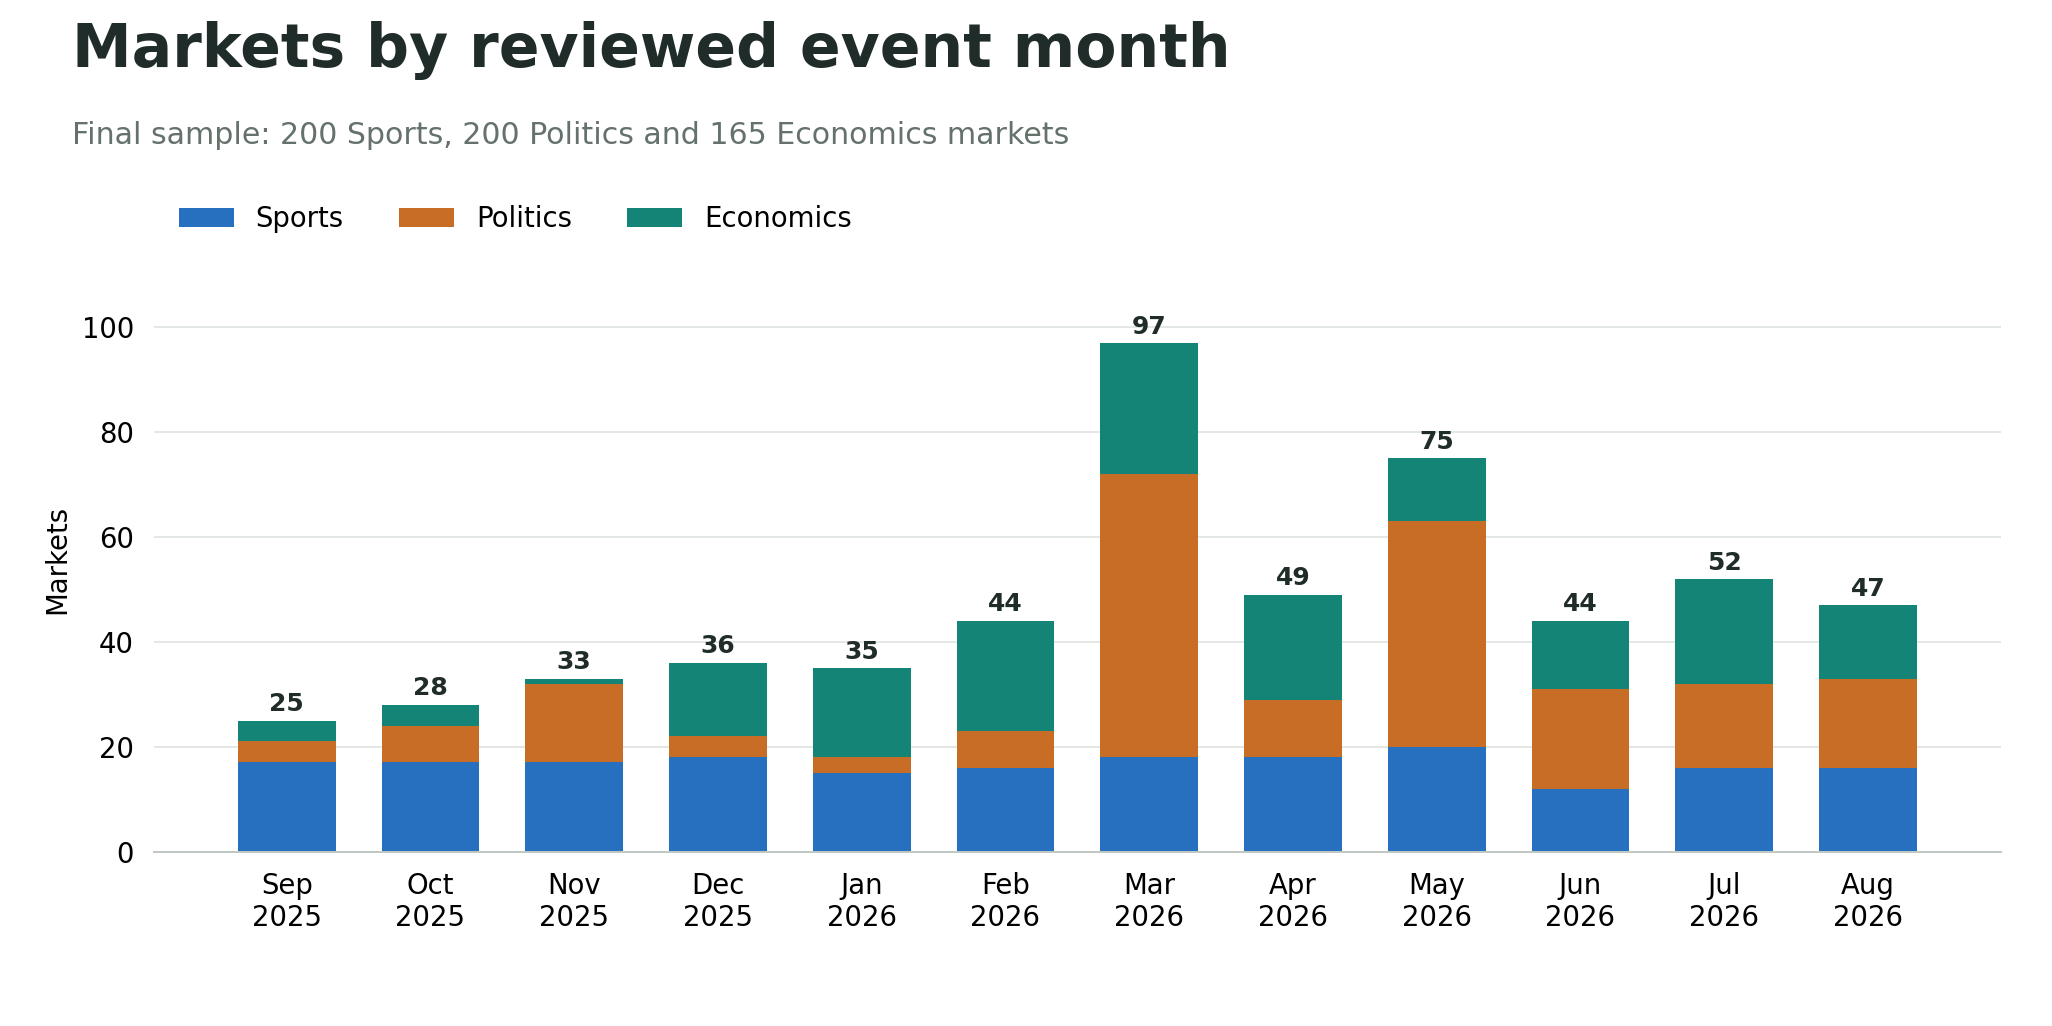

In [3]:
# Website source figure 02: current final sample.
def render_website_figure_02():
    from pathlib import Path
    import hashlib, json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter, MaxNLocator

    root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    data = root / 'data/eda/20260916_v2'
    output = root / 'figures/eda_20260917_final_refresh'
    output.mkdir(parents=True, exist_ok=True)
    manifest = json.loads((data / 'manifest.json').read_text(encoding='utf-8'))
    input_hashes = {}
    def load_checked(name):
        digest = hashlib.sha256((data / name).read_bytes()).hexdigest()
        assert digest == manifest['output_sha256'][name]
        input_hashes[name] = digest
        return pd.read_parquet(data / name)
    markets = load_checked('markets.parquet')
    topics = ['Sports', 'Politics', 'Economics']
    colors = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
    assert markets.groupby('topic').size().reindex(topics).tolist() == [200, 200, 165]
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'svg.fonttype': 'none', 'text.parse_math': False})
    stem = '02_event_month'
    # Count each retained market once using the independently reviewed event time.
    months = pd.period_range('2025-09', '2026-08', freq='M').astype(str)
    computed_month = markets.event_time_utc.dt.strftime('%Y-%m')
    assert computed_month.equals(markets.event_month)
    assert computed_month.isin(months).all()
    assert markets.sampling_month.notna().all()
    changed = markets.event_month.ne(markets.sampling_month)
    assert changed.equals(markets.sampling_month_differs)
    chart = pd.crosstab(markets.event_month, markets.topic).reindex(index=months, columns=topics, fill_value=0)
    assert int(chart.to_numpy().sum()) == 565
    assert chart.sum().tolist() == [200, 200, 165]
    for month in months:
        for topic in topics:
            assert chart.loc[month, topic] == int((computed_month.eq(month) & markets.topic.eq(topic)).sum())
    totals = chart.sum(axis=1)
    fig, ax = plt.subplots(figsize=(11.4, 5.7))
    fig.subplots_adjust(left=.075, right=.975, top=.74, bottom=.17)
    fig.text(.035, .935, 'Markets by reviewed event month', fontsize=24, weight='bold', color='#202C29')
    fig.text(.035, .86, 'Final sample: 200 Sports, 200 Politics and 165 Economics markets', fontsize=12, color='#65716B')
    bottom = np.zeros(len(months))
    for topic in topics:
        values = chart[topic].to_numpy(dtype=int)
        ax.bar(np.arange(len(months)), values, bottom=bottom, width=.68, color=colors[topic], label=topic)
        bottom += values
    for pos, total in enumerate(totals):
        ax.text(pos, total + 1.8, str(total), ha='center', fontsize=10, weight='bold', color='#202C29')
    ax.set_xticks(np.arange(len(months)), [pd.Period(m).strftime('%b\n%Y') for m in months])
    ax.set_ylabel('Markets')
    ax.set_ylim(0, max(totals) * 1.15)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.legend(ncol=3, frameon=False, loc='lower left', bbox_to_anchor=(0, 1.015))
    ax.grid(axis='y', color='#E4E8E4', linewidth=.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=8)
    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#BFC8C2')
    title = 'Audited event months'
    caption = (
        'The bars count all 565 final markets by their reviewed event month: 200 Sports, 200 Politics and 165 Economics. '
        'Twenty-nine markets have an event month different from their saved sampling month. The original draw was balanced '
        'across available months; event-date corrections, event-family replacements and available reserves changed the final distribution. '
        'The chart describes this sample, not the seasonal distribution of all Polymarket markets.'
    )
    alt = ('Stacked monthly counts for the final 565 markets, September 2025 through August 2026. '
           'Topic totals are Sports 200, Politics 200 and Economics 165. March 2026 has the largest total, 97 markets.')
    extra = dict(changed_sampling_months=int(changed.sum()), monthly_totals={k: int(v) for k, v in totals.items()})
    markets[['market_id', 'topic', 'event_time_utc', 'event_month', 'sampling_month', 'sampling_month_differs']].to_csv(output / '02_market_month_inputs.csv', index=False)
    chart = chart.reset_index(names='event_month')
    fig.savefig(output / (stem + '.png'), dpi=180)
    fig.savefig(output / (stem + '.svg'))
    plt.close(fig)
    chart.to_csv(output / (stem + '.csv'), index=False)
    details = dict(title=title, caption=caption, alt=alt, data_version='20260916_v2', markets=565,
                   topic_counts={'Sports': 200, 'Politics': 200, 'Economics': 165}, input_sha256=input_hashes,
                   checks_passed=True, **extra)
    (output / (stem + '_metadata.json')).write_text(json.dumps(details, indent=2) + '\n', encoding='utf-8')
    print(chart.to_string(index=False) if len(chart) < 30 else json.dumps(extra, indent=2))

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_02()

from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_final_refresh'
figure_details = json.loads((figure_output / '02_event_month_metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('02_event_month.' + extension), FIGURES / ('02_event_month.' + extension))
shutil.copy2(figure_output / '02_event_month.csv', FIGURES / 'chart_data/02_event_month.csv')
visuals.append(dict(id='02_event_month', title=figure_details['title'], caption=figure_details['caption'],
                    source='Complete calculation code in this notebook cell', footer='', png='02_event_month.png',
                    svg='02_event_month.svg', data='chart_data/02_event_month.csv'))
display(Image(filename=str(figure_output / '02_event_month.png')))


topic                  Sports  Politics  Economics
figure_group                                      
Two options               165         2          1
Three or more options      35        17        163
Count not verified          0       177          1
Questions can overlap       0         4          0


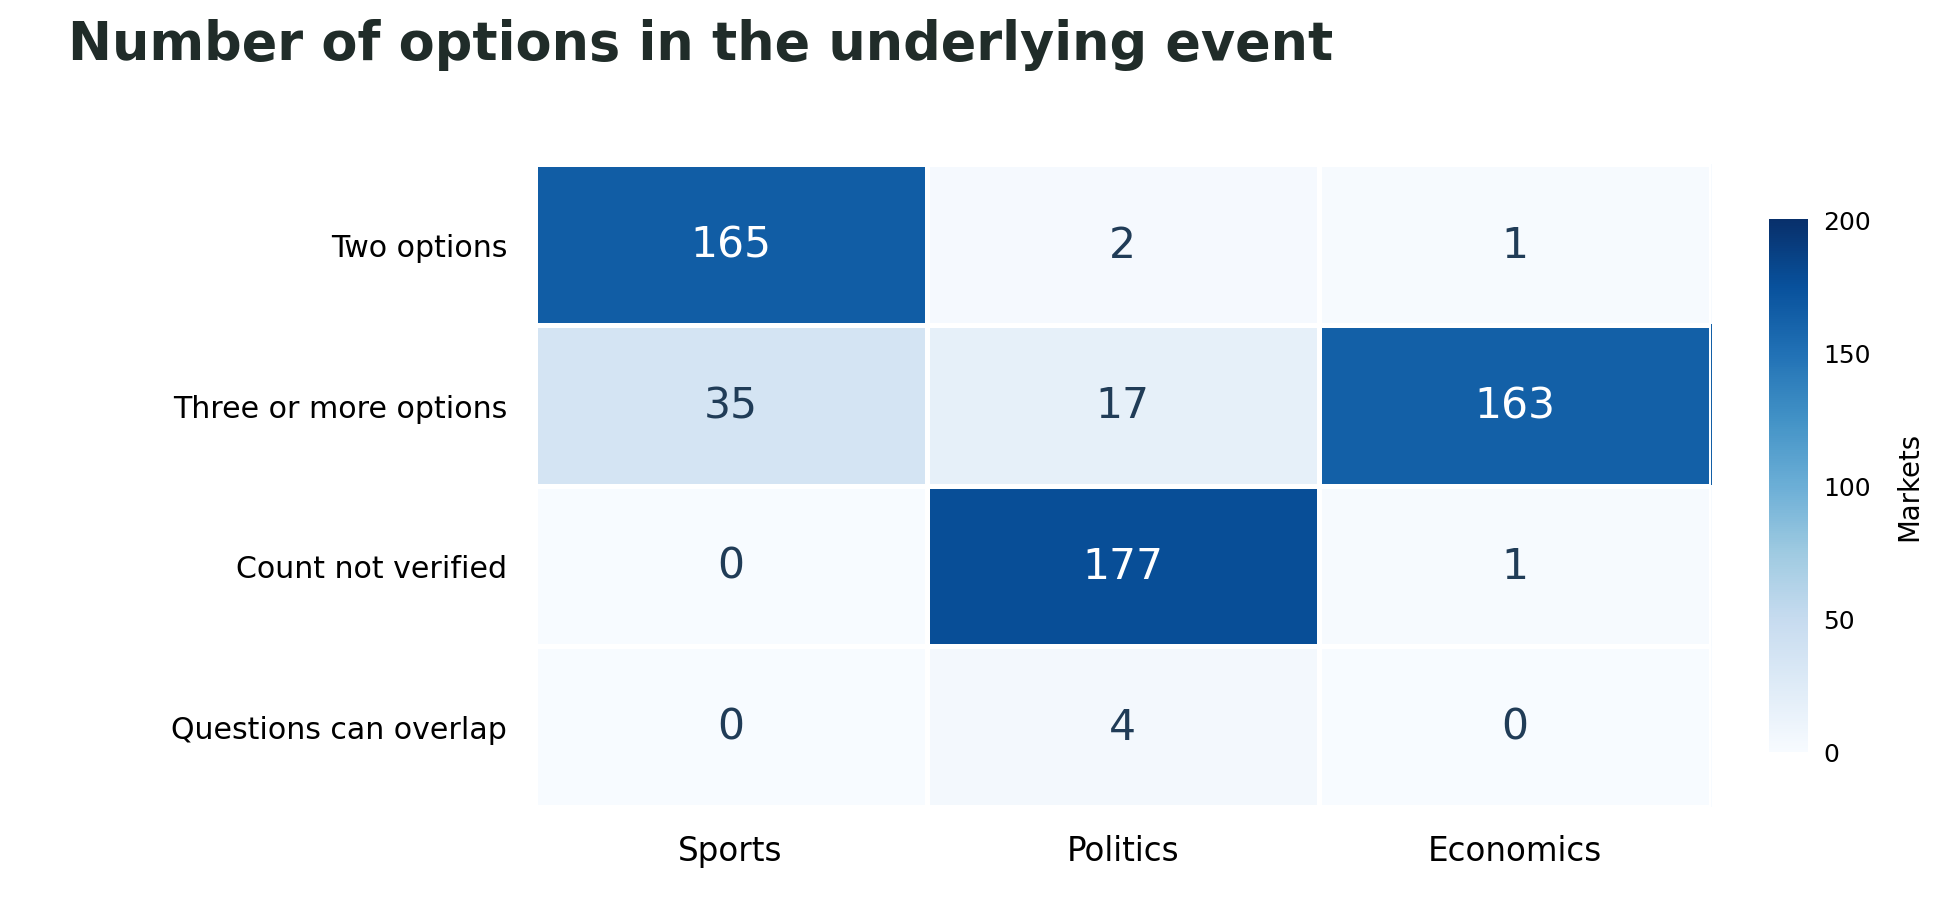

In [4]:
# Website source figure 03: complete calculations and rendering code.
def render_website_figure_03():
    """Simplify website Figure 04 using audited event-option counts.

    This is source figure 03 in the Word-transfer mapping. All sampled contracts
    are binary; the figure groups the alternatives in the underlying event.
    Unverified and nonexclusive groups remain separate from numerical counts.
    """
    import hashlib
    import json
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    DATA = ROOT / 'data/eda/20260916_v2'
    OUTPUT = ROOT / 'figures/eda_20260917_event_options'
    TOPICS = ['Sports', 'Politics', 'Economics']
    GROUPS = ['Two options', 'Three or more options', 'Count not verified', 'Questions can overlap']
    KNOWN = 'reconstructed_from_fixed_structure_and_timestamps'
    UNKNOWN = 'historical_count_unverified'
    NONEXCLUSIVE = 'not_applicable_nonexclusive_bundle'
    STEM = '03_event_options'


    def build_data():
        path = DATA / 'markets.csv'
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        manifest = json.loads((DATA / 'manifest.json').read_text(encoding='utf-8'))
        assert digest == manifest['output_sha256']['markets.csv']
        markets = pd.read_csv(path, dtype={'market_id': str})
        assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
        assert set(markets.option_count_status) == {KNOWN, UNKNOWN, NONEXCLUSIVE}
        known = markets.option_count_status.eq(KNOWN)
        unknown = markets.option_count_status.eq(UNKNOWN)
        nonexclusive = markets.option_count_status.eq(NONEXCLUSIVE)
        counts = markets.option_count_at_cutoff
        assert counts[known].notna().all()
        assert (counts[known] >= 2).all() and counts[known].mod(1).eq(0).all()
        assert counts[~known].isna().all()
        assert markets.loc[~nonexclusive, 'alternatives_mutually_exclusive'].eq(True).all()
        assert markets.loc[nonexclusive, 'alternatives_mutually_exclusive'].eq(False).all()
        masks = [known & counts.eq(2), known & counts.ge(3), unknown, nonexclusive]
        assert np.stack(masks).sum(axis=0).tolist() == [1] * len(markets)
        markets['figure_group'] = np.select(masks, GROUPS, default='UNCLASSIFIED')
        chart = pd.crosstab(markets.figure_group, markets.topic).reindex(index=GROUPS, columns=TOPICS, fill_value=0)
        assert chart.sum().to_dict() == {'Sports': 200, 'Politics': 200, 'Economics': 165}
        assert chart.sum(axis=1).tolist() == [168, 215, 178, 4]
        # Reconcile each cell to direct counts without the display grouping.
        for index, mask in enumerate(masks):
            for topic in TOPICS:
                assert chart.loc[GROUPS[index], topic] == int((mask & markets.topic.eq(topic)).sum())
        return chart, markets, digest


    def draw(chart):
        plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'svg.fonttype': 'none'})
        fig, ax = plt.subplots(figsize=(10.8, 5.1))
        fig.patch.set_facecolor('white')
        fig.subplots_adjust(left=.275, right=.88, top=.82, bottom=.12)
        fig.text(.035, .935, 'Number of options in the underlying event',
                 fontsize=21, weight='bold', color='#202C29')
        values = chart.to_numpy()
        heat = ax.imshow(values, cmap='Blues', vmin=0, vmax=200, aspect='auto', interpolation='nearest')
        ax.set_xticks(range(3), TOPICS, fontsize=13)
        ax.set_yticks(range(4), GROUPS, fontsize=12)
        ax.tick_params(axis='both', length=0, pad=11)
        for spine in ax.spines.values():
            spine.set_visible(False)
        # White borders keep small and zero-count cells readable.
        ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=2)
        ax.tick_params(which='minor', bottom=False, left=False)
        for row in range(4):
            for col in range(3):
                value = int(values[row, col])
                ax.text(col, row, str(value), ha='center', va='center', fontsize=17,
                        color='white' if value >= 115 else '#203C57')
        bar_ax = fig.add_axes([.91, .18, .02, .58])
        bar = fig.colorbar(heat, cax=bar_ax, ticks=[0, 50, 100, 150, 200])
        bar.outline.set_visible(False)
        bar.ax.tick_params(length=0, labelsize=10, pad=6)
        bar.set_label('Markets', labelpad=10, fontsize=11)
        return fig


    def main():
        chart, markets, digest = build_data()
        OUTPUT.mkdir(parents=True, exist_ok=True)
        chart.rename_axis('event_options').to_csv(OUTPUT / 'event_options.csv')
        markets[['market_id', 'topic', 'event_structure', 'option_count_status',
                 'option_count_at_cutoff', 'alternatives_mutually_exclusive', 'figure_group']].to_csv(
                     OUTPUT / 'market_option_groups.csv', index=False)
        fig = draw(chart)
        fig.savefig(OUTPUT / f'{STEM}.png', dpi=180)
        fig.savefig(OUTPUT / f'{STEM}.svg')
        plt.close(fig)
        caption = (
            'All sampled contracts have two outcomes. This chart counts the options in the wider event at the forecast cutoff: '
            'for example, two teams, three match results including a draw, or several election candidates or economic ranges. '
            'The saved audit reconstructs two options for 168 markets and three or more for 215. '
            'The count could not be verified for 178; four have questions that can overlap, so more than one can resolve Yes. '
            'Each market appears once. Counts use the final 565-market sample: 200 Sports, 200 Politics and 165 Economics.'
        )
        alt = ('Heatmap of underlying event options. Sports: 165 two options, 35 three or more, zero unverified or overlapping. '
               'Politics: 2 two options, 17 three or more, 177 count not verified, 4 overlapping. '
               'Economics: 1 two options, 163 three or more, 1 count not verified, zero overlapping.')
        metadata = dict(title='Number of event options', caption=caption, alt=alt,
                        source='data/eda/20260916_v2/markets.csv', source_sha256=digest,
                        included_markets=565, figure_source_id='03', website_display_number=4,
                        grouping_fields=['option_count_status', 'option_count_at_cutoff', 'alternatives_mutually_exclusive'],
                        group_totals={key: int(val) for key, val in chart.sum(axis=1).items()},
                        checks_passed=True,
                        limitation='Reconstructed historical counts are not contemporaneous menus or counts of actual eligible candidates; unknown counts are not inferred from current listings.')
        (OUTPUT / 'metadata.json').write_text(json.dumps(metadata, indent=2) + '\n', encoding='utf-8')
        (OUTPUT / 'README.md').write_text(
            '# Number of event options\n\n' + caption + '\n\n'
            'The audited historical option count and its status define four mutually exclusive display groups. '
            'Unverified counts stay missing; nonexclusive questions do not receive an invented option count. '
            'The 565-market grouping is descriptive and does not change eligibility.\n\n'
            '[PNG](03_event_options.png) | [SVG](03_event_options.svg) | [Chart data](event_options.csv) | '
            '[Market-level mapping](market_option_groups.csv) | [Provenance and checks](metadata.json)\n\n'
            'Rebuild with `python -X utf8 -B src/render_event_options.py`.\n', encoding='utf-8')
        print(chart.to_string())


    main()

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_03()

# Register the current figure in the notebook gallery and show its actual output.
from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_event_options'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('03_event_options.' + extension), FIGURES / ('03_event_structures.' + extension))
shutil.copy2(figure_output / 'event_options.csv', FIGURES / 'chart_data/03_event_structures.csv')
visuals.append(dict(id='03_event_structures', title=figure_details.get('title', 'Market pool, replacements and final cohort'),
                    caption=figure_details['caption'], source='Complete calculation code in this notebook cell', footer='',
                    png='03_event_structures.png', svg='03_event_structures.svg', data='chart_data/03_event_structures.csv'))
display(Image(filename=str(figure_output / '03_event_options.png')))


## 2. Extreme records and observation coverage

An unavailable value keeps its reason. No-returned-trade windows have zero counts and summed account activity, while mean trade size and concentration are undefined. Unknown historical option counts differ from nonexclusive groups for which a single count is not applicable.

### Very large recorded trades

A descriptive threshold above the pooled 99.9th percentile of price times shares identifies the largest 0.1% of returned records. We group flagged records by market and transaction ID for display to avoid counting multiple sides or records in one transaction as separate dots. This is a size screen, not evidence of informed trading. Fixed dollar thresholds and exact-repeat sensitivity are checked below; the source tables and missingness audit are unchanged.


    topic  all_records  all_transactions  flagged_records  flagged_transactions  flagged_markets  flagged_transaction_share
   Sports        19270              7955                1                     1                1                   0.000126
 Politics        48222             19272                2                     2                2                   0.000104
Economics        87685             35784              153                   110                4                   0.003074
 threshold_dollars  records  transactions  markets  Sports_transactions  Politics_transactions  Economics_transactions
      10000.000000      231           176       13                    4                      8                     164
      20539.678691      156           113        7                    1                      2                     110
      25000.000000      139           100        5                    1                      1                      98
      50000.000000       46 

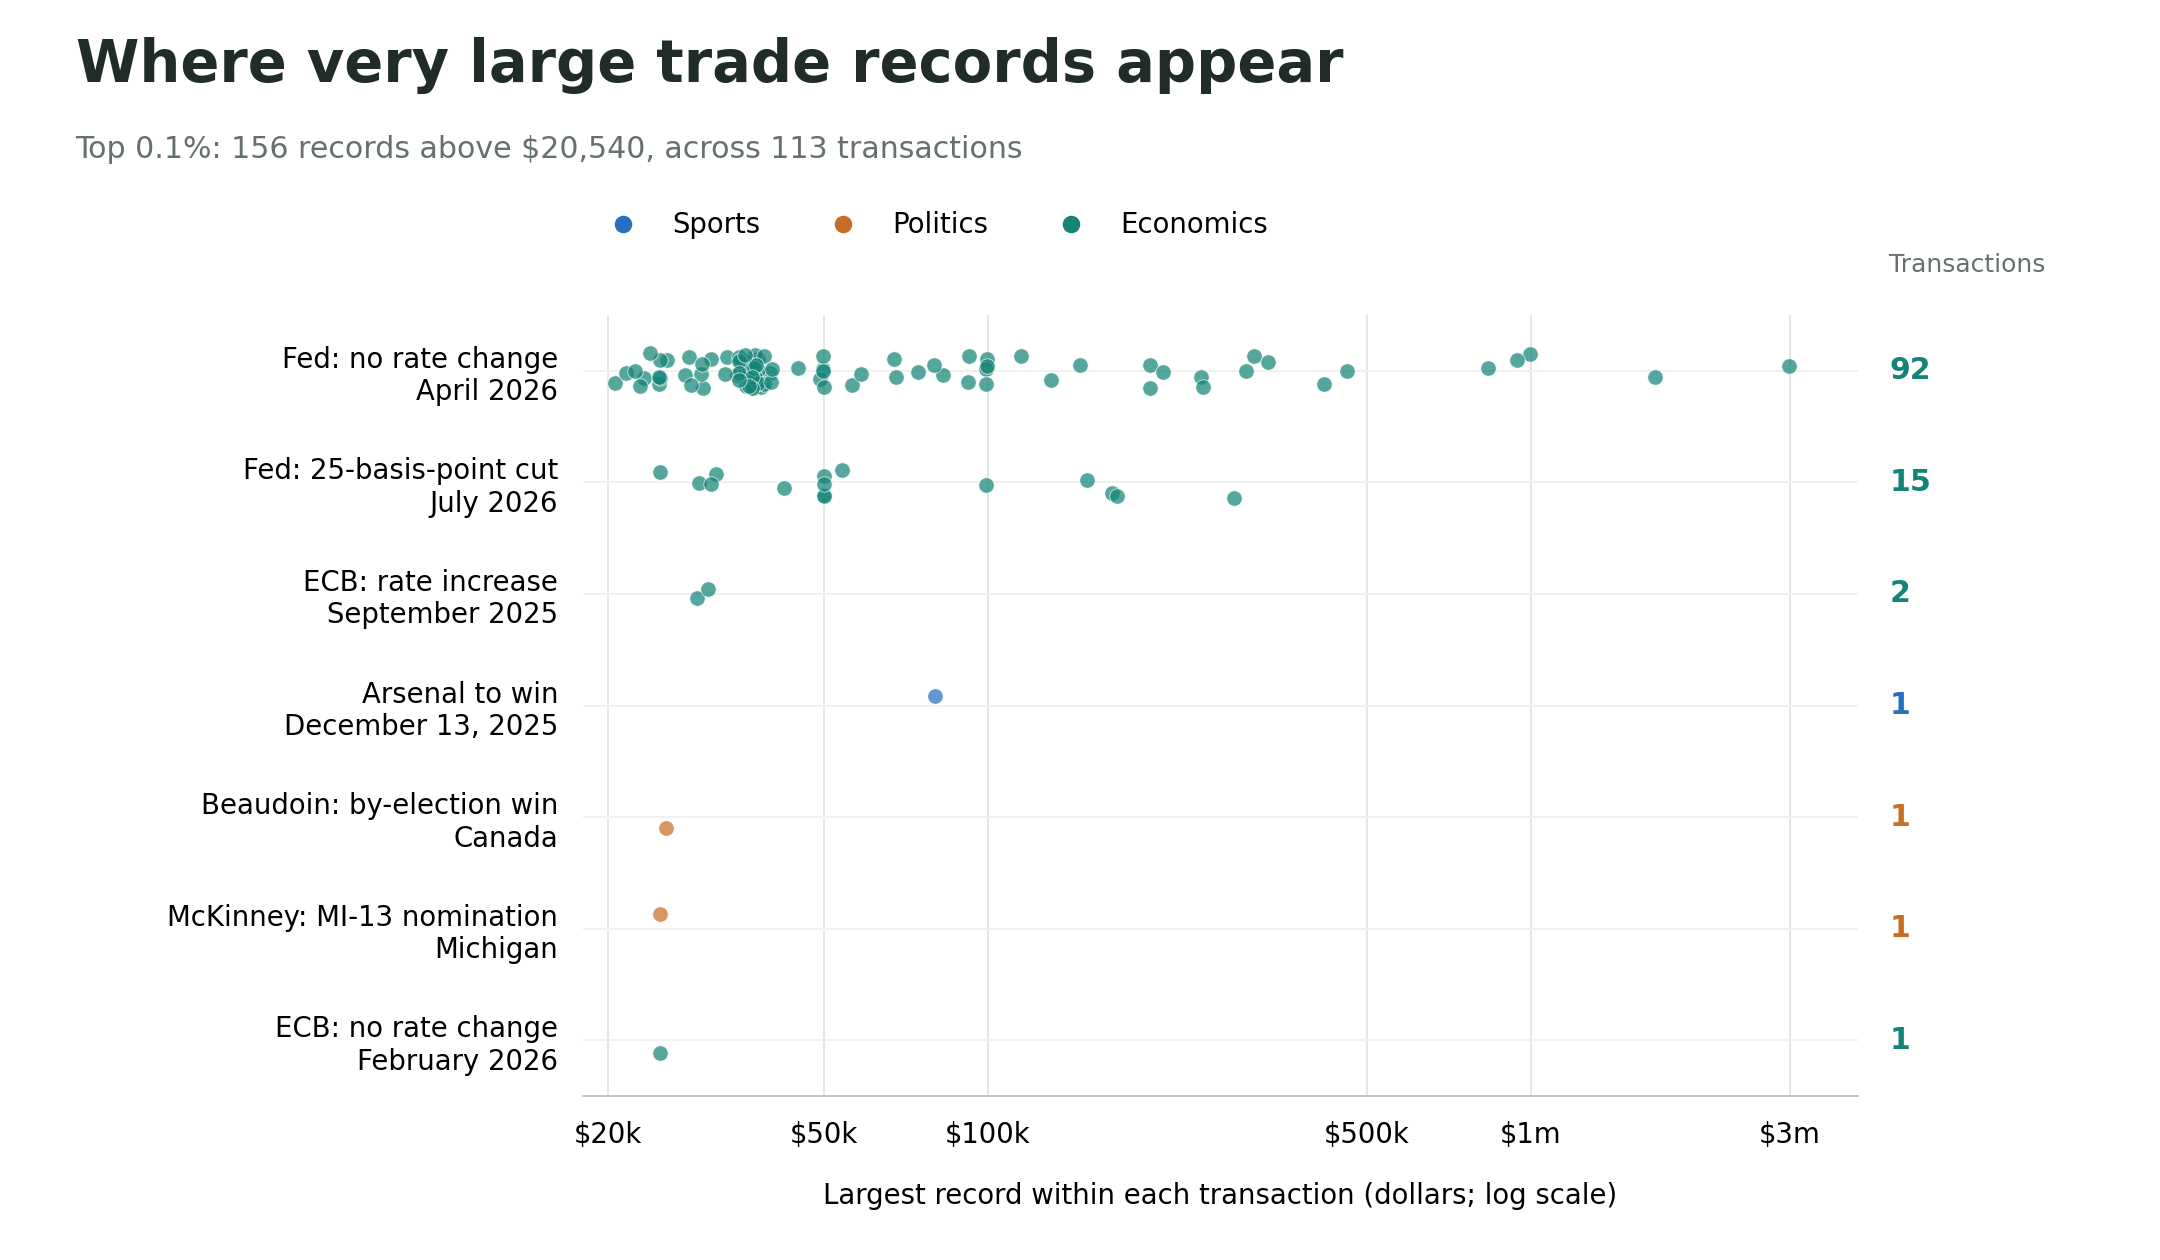

In [5]:
# Website source figure 04: a descriptive screen for unusually large records.
def render_website_figure_04():
    from pathlib import Path
    import gzip, hashlib, json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

    root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    data = root / 'data/eda/20260916_v2'
    output = root / 'figures/eda_20260917_large_trades'
    output.mkdir(parents=True, exist_ok=True)
    topics = ['Sports', 'Politics', 'Economics']
    colors = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    manifest = json.loads((data / 'manifest.json').read_text(encoding='utf-8'))
    hashes = {}
    for name in ['markets.parquet', 'trades.parquet']:
        hashes[name] = hashlib.sha256((data / name).read_bytes()).hexdigest()
        assert hashes[name] == manifest['output_sha256'][name]
    markets = pd.read_parquet(data / 'markets.parquet')
    trades = pd.read_parquet(data / 'trades.parquet')
    assert len(markets) == markets.market_id.nunique() == 565
    assert len(trades) == 155177 and trades.trade_row_id.nunique() == len(trades)
    assert np.allclose(trades.row_notional.astype(float), (trades.price * trades['size']).astype(float), rtol=1e-12, atol=0)
    assert trades.row_notional.gt(0).all() and np.isfinite(trades.row_notional.astype(float)).all()
    trades = trades.merge(markets[['market_id', 'topic', 'question', 'forecast_cutoff_utc', 'window_start_utc']],
                          on='market_id', validate='many_to_one')
    assert trades.topic.notna().all()
    assert (trades.trade_time_utc <= trades.forecast_cutoff_utc).all()
    assert (trades.trade_time_utc >= trades.window_start_utc).all()

    # A pooled empirical tail threshold, not a test that a wallet is informed.
    # Strictly above the linearly interpolated 99.9th percentile of all rows.
    threshold = float(trades.row_notional.quantile(.999, interpolation='linear'))
    flagged = trades[trades.row_notional > threshold].copy()
    assert len(flagged) == 156
    # Group only for display: one dot per market/transaction, sized by its
    # largest returned record. This is not reconstructed exchange turnover.
    groups = flagged.groupby(['market_id', 'transaction_hash'], as_index=False).agg(
        largest_record_dollars=('row_notional', 'max'), flagged_records=('trade_row_id', 'size'),
        trade_time_utc=('trade_time_utc', 'min'), wallets=('wallet_address', 'nunique'))
    groups = groups.merge(markets[['market_id', 'topic', 'question']], on='market_id', validate='many_to_one')
    assert len(groups) == groups.transaction_hash.nunique() == 113
    assert groups.flagged_records.sum() == len(flagged)
    assert groups.market_id.nunique() == 7
    counts = groups.groupby(['market_id', 'topic', 'question'], as_index=False).agg(
        transactions=('transaction_hash', 'size'), flagged_records=('flagged_records', 'sum'),
        largest_record_dollars=('largest_record_dollars', 'max'))
    counts = counts.sort_values(['transactions', 'largest_record_dollars', 'market_id'], ascending=[False, False, True])
    labels = {
        '669662': 'Fed: no rate change\nApril 2026',
        '1654957': 'Fed: 25-basis-point cut\nJuly 2026',
        '567502': 'ECB: rate increase\nSeptember 2025',
        '768263': 'Arsenal to win\nDecember 13, 2025',
        '1695434': 'Beaudoin: by-election win\nCanada',
        '973278': 'McKinney: MI-13 nomination\nMichigan',
        '678118': 'ECB: no rate change\nFebruary 2026',
    }
    assert set(counts.market_id) == set(labels)
    topic_rows = []
    for topic in topics:
        all_topic = trades[trades.topic == topic]
        f = flagged[flagged.topic == topic]
        g = groups[groups.topic == topic]
        topic_rows.append(dict(topic=topic, all_records=len(all_topic), all_transactions=all_topic.transaction_hash.nunique(),
                               flagged_records=len(f), flagged_transactions=len(g), flagged_markets=f.market_id.nunique(),
                               flagged_transaction_share=len(g) / all_topic.transaction_hash.nunique()))
    topic_summary = pd.DataFrame(topic_rows)
    assert topic_summary.flagged_transactions.tolist() == [1, 2, 110]
    sensitivity = []
    for cutoff in [10000., threshold, 25000., 50000., 100000.]:
        subset = trades[trades.row_notional > cutoff]
        per_topic = subset.groupby('topic').transaction_hash.nunique().reindex(topics, fill_value=0)
        sensitivity.append(dict(threshold_dollars=cutoff, records=len(subset), transactions=subset.transaction_hash.nunique(),
                                markets=subset.market_id.nunique(), **{t + '_transactions': int(per_topic[t]) for t in topics}))
    # Collapsing exact repeats is a diagnostic only; the retained records stay intact.
    collapsed = flagged[~flagged.duplicate_excess]
    assert len(collapsed) == 155
    assert set(zip(collapsed.market_id, collapsed.transaction_hash)) == set(zip(groups.market_id, groups.transaction_hash))
    # Check the three largest records directly against their saved API captures.
    largest_source_checks = []
    for row in flagged.nlargest(3, 'row_notional').itertuples():
        path = root / row.source_file
        assert hashlib.sha256(path.read_bytes()).hexdigest() == row.source_file_sha256
        original = json.loads(gzip.decompress(path.read_bytes()))[int(row.source_row_index)]
        assert original['transactionHash'].lower() == row.transaction_hash
        assert original['proxyWallet'].lower() == row.wallet_address
        assert np.isclose(float(original['price']) * float(original['size']), float(row.row_notional), rtol=1e-12, atol=0)
        largest_source_checks.append(dict(trade_row_id=row.trade_row_id, source_file=row.source_file, source_row_index=int(row.source_row_index)))

    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'svg.fonttype': 'none', 'text.parse_math': False})
    fig, ax = plt.subplots(figsize=(12.0, 7.0))
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(left=.27, right=.86, top=.75, bottom=.13)
    fig.text(.035, .935, 'Where very large trade records appear', fontsize=23, weight='bold', color='#202C29')
    fig.text(.035, .875, f'Top 0.1%: {len(flagged)} records above ${threshold:,.0f}, across {len(groups)} transactions',
             fontsize=12, color='#65716B')
    for pos, row in enumerate(counts.itertuples()):
        g = groups[groups.market_id == row.market_id]
        # Deterministic vertical offsets reveal overlapping dots; dollar values never move.
        jitter = np.array([(int(hashlib.sha256(h.encode()).hexdigest()[:8], 16) / (16**8-1) - .5) * .32
                           for h in g.transaction_hash])
        ax.scatter(g.largest_record_dollars.astype(float), pos + jitter, s=38, color=colors[row.topic],
                   alpha=.72, edgecolors='white', linewidths=.35, zorder=3)
        ax.text(1.025, pos, str(row.transactions), transform=ax.get_yaxis_transform(), va='center',
                fontsize=12, weight='bold', color=colors[row.topic])
    ax.text(1.025, 1.055, 'Transactions', transform=ax.transAxes, fontsize=10, color='#65716B')
    ax.set_yticks(range(len(counts)), [labels[mid] for mid in counts.market_id], fontsize=11)
    ax.set_ylim(len(counts)-.5, -.5)
    ax.set_xscale('log')
    ax.set_xlim(18000, 4000000)
    ax.xaxis.set_major_locator(FixedLocator([20000, 50000, 100000, 500000, 1000000, 3000000]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1000000:g}m' if x >= 1000000 else f'${x/1000:g}k'))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xlabel('Largest record within each transaction (dollars; log scale)', labelpad=13)
    ax.grid(axis='x', color='#E4E8E4', linewidth=.8)
    ax.grid(axis='y', color='#F0F2F0', linewidth=.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=10)
    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#BFC8C2')
    ax.legend(handles=[Line2D([], [], marker='o', linestyle='none', color=colors[t], label=t) for t in topics],
              loc='lower left', bbox_to_anchor=(-.01, 1.065), ncol=3, frameon=False, fontsize=11)
    fig.savefig(output / '04_large_trade_records.png', dpi=180)
    fig.savefig(output / '04_large_trade_records.svg')
    plt.close(fig)

    caption = (
        f'For this descriptive screen, very large means above the pooled 99.9th percentile of price times shares (${threshold:,.2f}). '
        'This flags 156 returned BUY/SELL records across 113 transaction IDs and seven markets. '
        'Each dot represents a transaction containing at least one flagged record; its position shows the largest record in that transaction. '
        'Economics accounts for 110 of the 113 transactions, including 92 in the April 2026 Fed no-change market and 15 in the July Fed cut market. '
        'The largest record is $2.994 million. These observations come from the collected pre-cutoff windows, not full market lifetimes. '
        'This threshold identifies an extreme size range, not proven informed whales or unique exchange fills; 154 of the 156 records have token prices of at least $0.90.'
    )
    alt = ('Dot plot of 113 transactions containing records above about $20,540. '
           'April Fed no-change: 92; July Fed 25-basis-point cut: 15; September ECB increase: 2; '
           'Arsenal, Beaudoin, McKinney and February ECB no-change: 1 each. Maximum record is $2.994 million.')
    summary = dict(title='Very large trade records', caption=caption, alt=alt, threshold_dollars=threshold,
                   quantile=.999, quantile_interpolation='linear', selection_rule='row_notional > threshold',
                   all_records=len(trades), flagged_records=len(flagged), transactions=len(groups), markets=7,
                   wallets=flagged.wallet_address.nunique(), max_record_dollars=float(flagged.row_notional.max()),
                   records_at_price_at_least_90_cents=int(flagged.price.ge(.9).sum()),
                   duplicate_excess_flagged=int(flagged.duplicate_excess.sum()), collapsed_flagged_records=len(collapsed),
                   grouping_preserved_after_repeat_collapse=True, input_sha256=hashes,
                   largest_source_checks=largest_source_checks, checks_passed=True)
    for filename, frame in [('flagged_records.csv', flagged), ('large_transactions.csv', groups),
                            ('market_summary.csv', counts), ('topic_summary.csv', topic_summary),
                            ('threshold_sensitivity.csv', pd.DataFrame(sensitivity))]:
        frame.to_csv(output / filename, index=False)
    month_counts = groups.assign(trade_month=groups.trade_time_utc.dt.strftime('%Y-%m')).groupby('trade_month').size()
    month_counts.rename('transactions').to_csv(output / 'trade_month_summary.csv')
    (output / 'metadata.json').write_text(json.dumps(summary, indent=2) + '\n', encoding='utf-8')
    (output / 'README.md').write_text('# Very large recorded trades\n\n' + caption + '\n\n'
        'The pooled 99.9th-percentile cutoff is an explicit descriptive choice, not a statistical test or universal whale definition. '
        'Raw-dollar three-IQR screening would start near $76 because the median record is about $4.32, so it does not isolate the very large plays requested here. '
        'Sensitivity exports also check fixed $10k, $25k, $50k and $100k cutoffs. Economics remains the main location across these choices. '
        'The concentration in April and July is driven by these particular Fed markets; it is not evidence of a seasonal effect. '
        'Large dollar consideration at prices close to $1 does not establish unusual information or forecast skill.\n\n'
        'Repeated rows remain retained. Grouping for the plot counts each market/transaction ID once and uses its maximum individual record, '
        'not the sum of counterparties or an estimate of transaction turnover. Collapsing the one flagged excess exact repeat leaves all 113 plotted groups unchanged. '
        'The largest three records match their saved API captures; this is not independent on-chain verification.\n\n'
        'All calculation and plotting code is in the tagged source-04 cell of `notebooks/02_cohort_eda.ipynb`. '
        'Raw source data, eligibility decisions and the missingness audit remain intact.\n', encoding='utf-8')
    print(topic_summary.to_string(index=False))
    print(pd.DataFrame(sensitivity).to_string(index=False))

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_04()

from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_large_trades'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('04_large_trade_records.' + extension), FIGURES / ('04_large_trade_records.' + extension))
shutil.copy2(figure_output / 'market_summary.csv', FIGURES / 'chart_data/04_large_trade_records.csv')
visuals.append(dict(id='04_large_trade_records', title=figure_details['title'], caption=figure_details['caption'],
                    source='Complete calculation code in this notebook cell', footer='', png='04_large_trade_records.png',
                    svg='04_large_trade_records.svg', data='chart_data/04_large_trade_records.csv'))
display(Image(filename=str(figure_output / '04_large_trade_records.png')))


    topic  total_markets  full_window_markets  short_window_markets  full_window_share  short_window_share  min_window_hours  median_window_hours
   Sports            200                   43                   157           0.215000            0.785000          0.988056           121.949861
 Politics            200                  175                    25           0.875000            0.125000          6.747778           168.000000
Economics            165                  153                    12           0.927273            0.072727        109.049444           168.000000


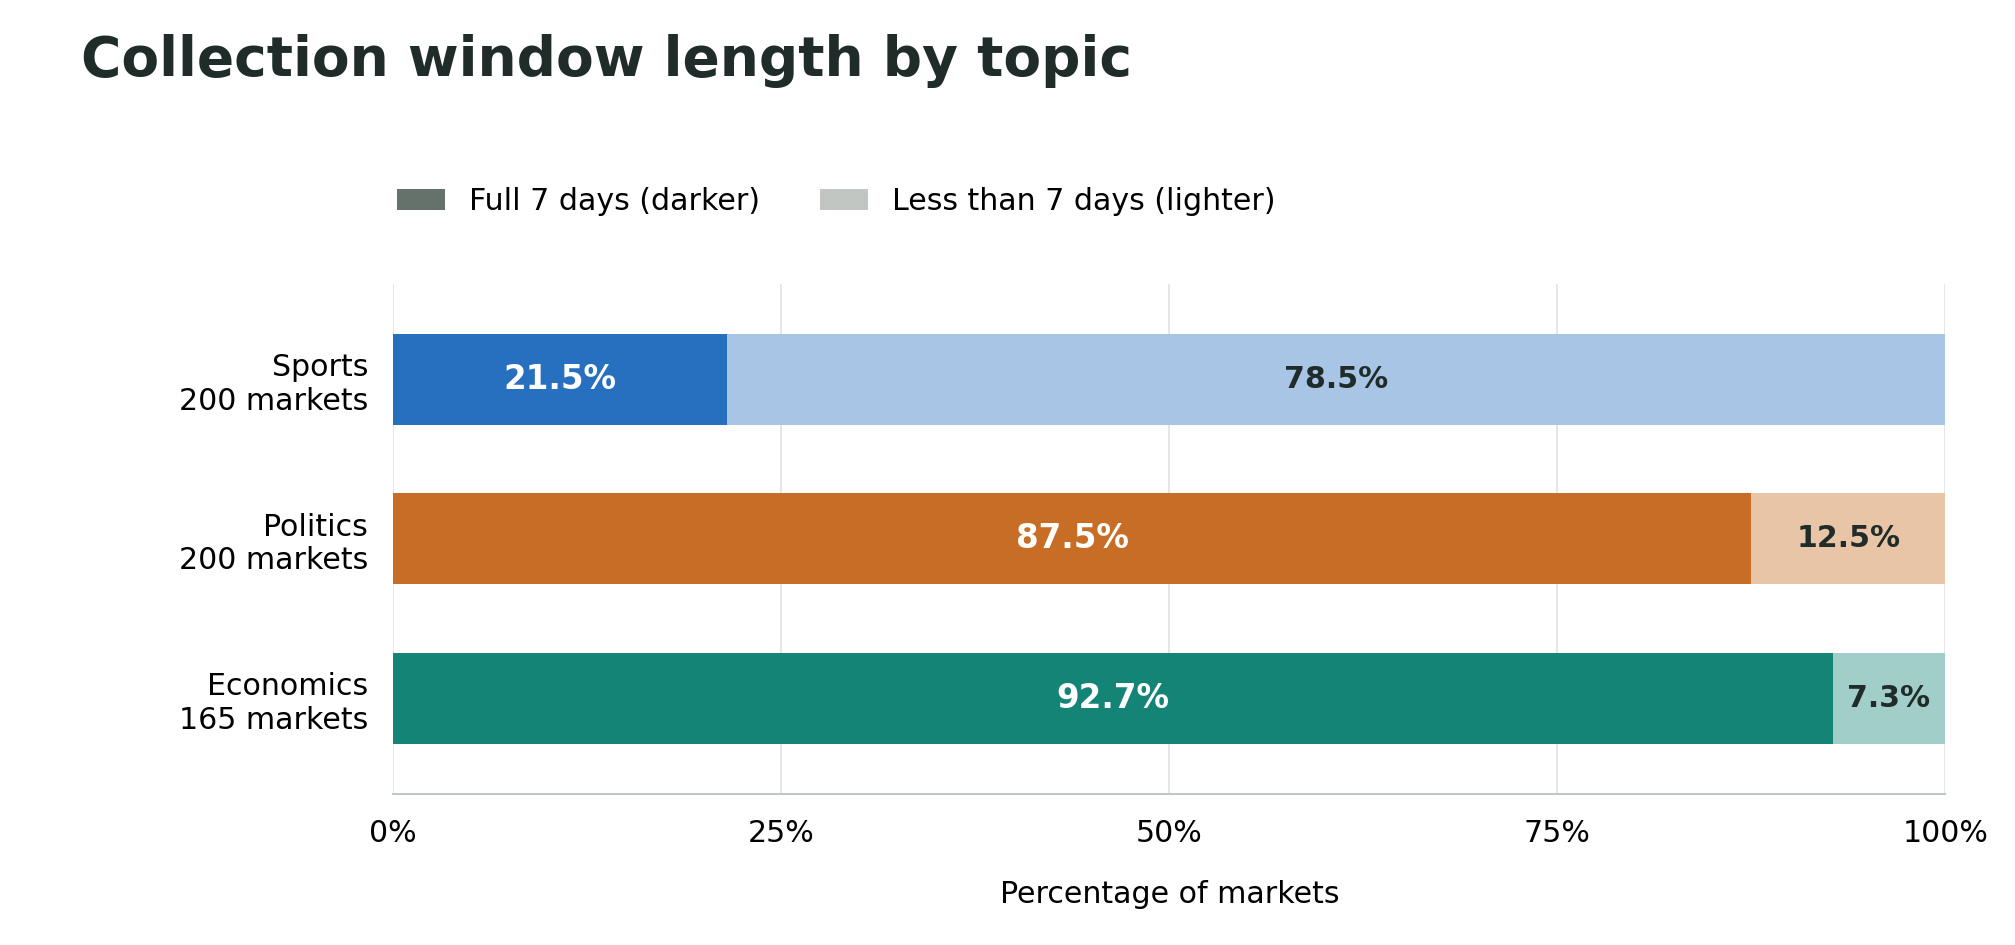

In [6]:
# Website source figure 05: complete calculations and rendering code.
def render_website_figure_05():
    """Figure 06 (source 05): full-week versus shorter collection windows.

    Uses requested window duration, not the distance between the first and last
    returned trade. Source durations and histories remain unchanged.
    """
    import hashlib
    import json
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.colors import to_rgb
    from matplotlib.patches import Patch
    from matplotlib.ticker import PercentFormatter
    import numpy as np
    import pandas as pd

    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    DATA = ROOT / 'data/eda/20260916_v2'
    OUTPUT = ROOT / 'figures/eda_20260917_window_duration'
    TOPICS = ['Sports', 'Politics', 'Economics']
    COLORS = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    STEM = '05_window_duration'


    def build_data():
        path = DATA / 'markets.csv'
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        manifest = json.loads((DATA / 'manifest.json').read_text(encoding='utf-8'))
        assert digest == manifest['output_sha256']['markets.csv']
        markets = pd.read_csv(path, dtype={'market_id': str})
        assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
        hours = markets.window_hours
        assert hours.notna().all() and hours.gt(0).all() and hours.le(168).all()
        assert hours.lt(168).equals(markets.short_window)
        elapsed = (pd.to_datetime(markets.forecast_cutoff_utc, utc=True) -
                   pd.to_datetime(markets.window_start_utc, utc=True)).dt.total_seconds() / 3600
        assert np.allclose(elapsed, hours, atol=1e-8, rtol=0)
        markets['window_group'] = np.where(hours.eq(168), 'Full 7 days', 'Less than 7 days')
        rows = []
        for topic in TOPICS:
            group = markets[markets.topic.eq(topic)]
            full = int(group.window_hours.eq(168).sum())
            short = int(group.window_hours.lt(168).sum())
            assert full + short == len(group)
            rows.append(dict(topic=topic, total_markets=len(group), full_window_markets=full,
                             short_window_markets=short, full_window_share=full / len(group),
                             short_window_share=short / len(group),
                             min_window_hours=float(group.window_hours.min()),
                             median_window_hours=float(group.window_hours.median())))
        chart = pd.DataFrame(rows)
        assert chart.total_markets.tolist() == [200, 200, 165]
        assert chart.short_window_markets.tolist() == [157, 25, 12]
        assert chart.full_window_markets.sum() == 371
        assert chart.short_window_markets.sum() == 194
        return markets, chart, digest


    def draw(chart):
        plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'svg.fonttype': 'none'})
        fig, ax = plt.subplots(figsize=(11.2, 5.25))
        fig.patch.set_facecolor('white')
        fig.subplots_adjust(left=.195, right=.965, top=.70, bottom=.16)
        fig.text(.04, .92, 'Collection window length by topic', fontsize=22, weight='bold', color='#202C29')
        positions = np.arange(3)
        colors = [COLORS[topic] for topic in chart.topic]
        light_colors = [tuple(.40 * value + .60 for value in to_rgb(color)) for color in colors]
        ax.barh(positions, chart.full_window_share, height=.57, color=colors)
        ax.barh(positions, chart.short_window_share, left=chart.full_window_share,
                height=.57, color=light_colors, linewidth=0)
        for y, row in zip(positions, chart.itertuples()):
            ax.text(row.full_window_share / 2, y, f'{100 * row.full_window_share:.1f}%',
                    ha='center', va='center', color='white', fontsize=13, weight='bold')
            ax.text(row.full_window_share + row.short_window_share / 2, y, f'{100 * row.short_window_share:.1f}%',
                    ha='center', va='center', color='#202C29', fontsize=12, weight='bold')
        ax.set_yticks(positions, [f'{r.topic}\n{r.total_markets} markets' for r in chart.itertuples()])
        ax.set(ylim=(2.6, -.6), xlim=(0, 1), xticks=np.linspace(0, 1, 5))
        ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
        ax.set_xlabel('Percentage of markets', labelpad=13)
        ax.set_axisbelow(True)
        ax.grid(axis='x', color='#E4E8E4', lw=.8)
        ax.legend(handles=[Patch(facecolor='#65716B', label='Full 7 days (darker)'),
                           Patch(facecolor='#C1C6C3', label='Less than 7 days (lighter)')],
                  loc='lower left', bbox_to_anchor=(-.015, 1.08), ncol=2,
                  frameon=False, fontsize=12, handlelength=1.6, columnspacing=2)
        for side in ['top', 'right', 'left']:
            ax.spines[side].set_visible(False)
        ax.spines['bottom'].set_color('#BFC8C2')
        ax.tick_params(length=0, pad=10)
        return fig


    def main():
        markets, chart, digest = build_data()
        OUTPUT.mkdir(parents=True, exist_ok=True)
        chart.to_csv(OUTPUT / 'window_duration_by_topic.csv', index=False)
        markets[['market_id', 'topic', 'window_start_utc', 'forecast_cutoff_utc',
                 'window_hours', 'short_window', 'window_group']].to_csv(OUTPUT / 'market_windows.csv', index=False)
        fig = draw(chart)
        fig.savefig(OUTPUT / f'{STEM}.png', dpi=180)
        fig.savefig(OUTPUT / f'{STEM}.svg')
        plt.close(fig)
        caption = (
            'Each bar represents all sampled markets in that topic. A full window covers seven days ending at the forecast cutoff, '
            '24 hours before the event boundary. Later-listed markets have shorter windows: 157 of 200 Sports markets (78.5%), '
            '25 of 200 Politics markets (12.5%) and 12 of 165 Economics markets (7.3%). '
            'In the final 565-market sample, 371 have full windows and 194 have shorter windows. '
            'These are the requested collection periods; shorter windows provide less time to observe trades and wallets.'
        )
        alt = ('Three 100-percent stacked bars compare full seven-day and shorter collection windows. '
               'Sports: 21.5% full and 78.5% shorter. Politics: 87.5% full and 12.5% shorter. '
               'Economics: 92.7% full and 7.3% shorter.')
        metadata = dict(title='Collection window length by topic', caption=caption, alt=alt,
                        source='data/eda/20260916_v2/markets.csv', source_sha256=digest,
                        source_figure_id='05', displayed_figure_number=6, included_markets=565,
                        full_windows=371, short_windows=194,
                        full_window_rule='window_hours == 168', short_window_rule='0 < window_hours < 168',
                        checks_passed=True,
                        verification='All durations match forecast_cutoff_utc minus window_start_utc; all short flags agree.',
                        limitation='Two categories simplify the comparison but do not show the duration distribution within shorter windows.')
        (OUTPUT / 'metadata.json').write_text(json.dumps(metadata, indent=2) + '\n', encoding='utf-8')
        (OUTPUT / 'README.md').write_text(
            '# Collection window length by topic\n\n' + caption + '\n\n'
            'The 100% stacked bars use each topic total as the denominator. '
            'This intentionally focuses on full-week versus shortened exposure; individual durations remain in the market-level export. '
            'Window length is measured from the collection start to the cutoff, not from returned record timestamps. '
            'A full collection window does not establish continuous observations throughout that interval.\n\n'
            'The final 565-market sample contains 194 shorter windows and 371 full seven-day windows.\n\n'
            '[PNG](05_window_duration.png) | [SVG](05_window_duration.svg) | [Chart data](window_duration_by_topic.csv) | '
            '[Market-level windows](market_windows.csv) | [Definitions and checks](metadata.json)\n\n'
            'Rebuild with `python -X utf8 -B src/render_window_duration.py`.\n', encoding='utf-8')
        print(chart.to_string(index=False))


    main()

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_05()

# Register the current figure in the notebook gallery and show its actual output.
from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_window_duration'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('05_window_duration.' + extension), FIGURES / ('05_window_duration.' + extension))
shutil.copy2(figure_output / 'window_duration_by_topic.csv', FIGURES / 'chart_data/05_window_duration.csv')
visuals.append(dict(id='05_window_duration', title=figure_details.get('title', 'Market pool, replacements and final cohort'),
                    caption=figure_details['caption'], source='Complete calculation code in this notebook cell', footer='',
                    png='05_window_duration.png', svg='05_window_duration.svg', data='chart_data/05_window_duration.csv'))
display(Image(filename=str(figure_output / '05_window_duration.png')))


    topic  total  zero_windows  percentage
   Sports    200            64   32.000000
 Politics    200             2    1.000000
Economics    165             1    0.606061


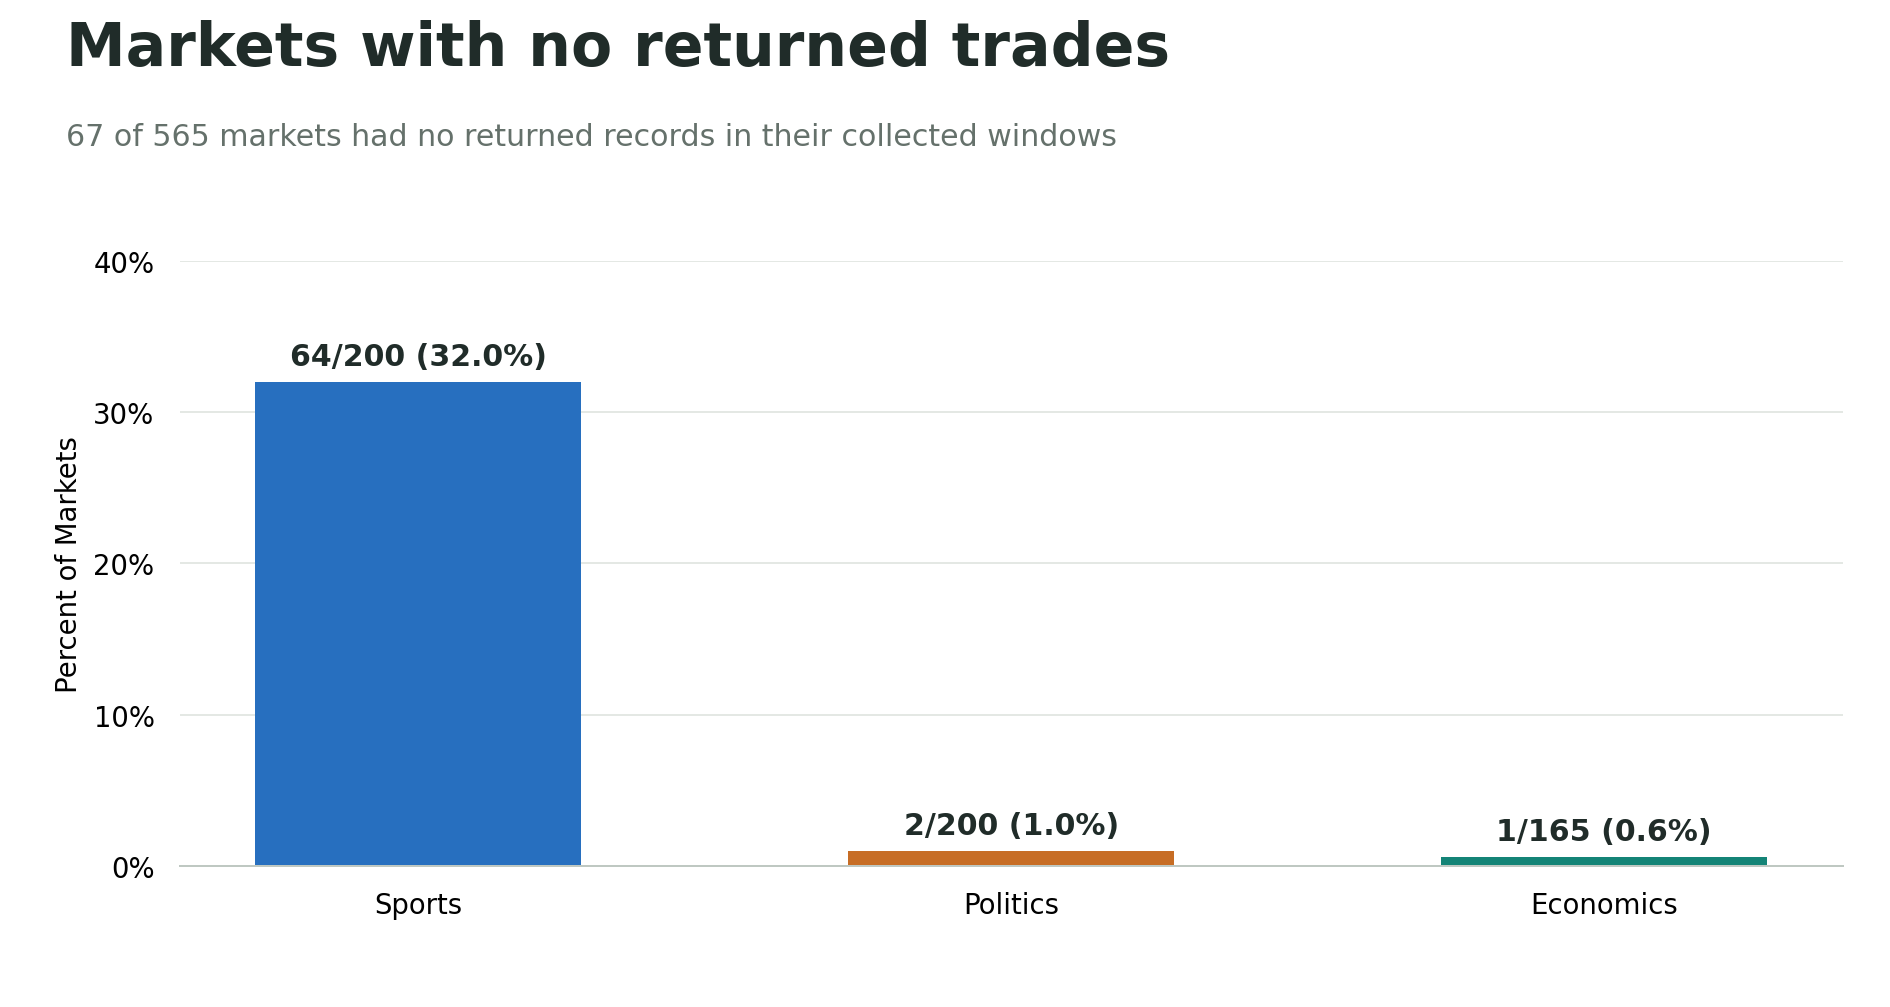

In [7]:
# Website source figure 06: current final sample.
def render_website_figure_06():
    from pathlib import Path
    import hashlib, json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter, MaxNLocator

    root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    data = root / 'data/eda/20260916_v2'
    output = root / 'figures/eda_20260917_final_refresh'
    output.mkdir(parents=True, exist_ok=True)
    manifest = json.loads((data / 'manifest.json').read_text(encoding='utf-8'))
    input_hashes = {}
    def load_checked(name):
        digest = hashlib.sha256((data / name).read_bytes()).hexdigest()
        assert digest == manifest['output_sha256'][name]
        input_hashes[name] = digest
        return pd.read_parquet(data / name)
    markets = load_checked('markets.parquet')
    topics = ['Sports', 'Politics', 'Economics']
    colors = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
    assert markets.groupby('topic').size().reindex(topics).tolist() == [200, 200, 165]
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'svg.fonttype': 'none', 'text.parse_math': False})
    stem = '06_zero_trade_windows'
    # Verify the zero-return flags directly from retained trade-row counts.
    trades = load_checked('trades.parquet')
    assert len(trades) == 155177
    observed_counts = trades.groupby('market_id').size().reindex(markets.market_id, fill_value=0).to_numpy(dtype=int)
    assert np.array_equal(observed_counts, markets.trade_row_count.to_numpy(dtype=int))
    assert np.array_equal(observed_counts == 0, markets.zero_returned_trades.to_numpy(dtype=bool))
    chart = markets.groupby('topic').agg(total=('market_id', 'size'), zero_windows=('zero_returned_trades', 'sum')).reindex(topics).reset_index()
    chart['percentage'] = 100 * chart.zero_windows / chart.total
    assert chart.zero_windows.tolist() == [64, 2, 1] and chart.zero_windows.sum() == 67
    assert chart.total.sum() == 565
    fig, ax = plt.subplots(figsize=(10.5, 5.6))
    fig.subplots_adjust(left=.095, right=.975, top=.74, bottom=.14)
    fig.text(.035, .935, 'Markets with no returned trades', fontsize=24, weight='bold', color='#202C29')
    fig.text(.035, .855, '67 of 565 markets had no returned records in their collected windows', fontsize=12, color='#65716B')
    ax.bar(topics, chart.percentage, color=[colors[t] for t in topics], width=.55)
    for pos, row in enumerate(chart.itertuples()):
        ax.text(pos, row.percentage + 1.1, f'{row.zero_windows}/{row.total} ({row.percentage:.1f}%)',
                ha='center', fontsize=12, weight='bold', color='#202C29')
    ax.set_ylabel('Percent of Markets')
    ax.set_ylim(0, 40)
    ax.set_yticks([0, 10, 20, 30, 40])
    ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
    ax.grid(axis='y', color='#E4E8E4', linewidth=.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=10)
    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#BFC8C2')
    title = 'No returned trades in the collected window'
    caption = (
        'The collected windows contain no returned trades for 64 of 200 Sports markets (32.0%), '
        'two of 200 Politics markets (1.0%) and one of 165 Economics markets (0.6%): 67 markets in total. '
        'All remain in the final 565-market sample. These windows cover up to seven days ending at the forecast cutoff; '
        'a zero count does not establish that a market had no trading earlier or during the final 24 hours before its event.'
    )
    alt = ('Bar chart of zero-returned-trade windows in the final sample. Sports 64 of 200, 32.0%; '
           'Politics 2 of 200, 1.0%; Economics 1 of 165, 0.6%. Total 67 of 565.')
    extra = dict(zero_windows=67, positive_windows=498, verified_from_trade_rows=True)
    markets[['market_id', 'topic', 'window_start_utc', 'forecast_cutoff_utc', 'trade_row_count', 'zero_returned_trades']].to_csv(output / '06_trade_window_inputs.csv', index=False)
    fig.savefig(output / (stem + '.png'), dpi=180)
    fig.savefig(output / (stem + '.svg'))
    plt.close(fig)
    chart.to_csv(output / (stem + '.csv'), index=False)
    details = dict(title=title, caption=caption, alt=alt, data_version='20260916_v2', markets=565,
                   topic_counts={'Sports': 200, 'Politics': 200, 'Economics': 165}, input_sha256=input_hashes,
                   checks_passed=True, **extra)
    (output / (stem + '_metadata.json')).write_text(json.dumps(details, indent=2) + '\n', encoding='utf-8')
    print(chart.to_string(index=False) if len(chart) < 30 else json.dumps(extra, indent=2))

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_06()

from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_final_refresh'
figure_details = json.loads((figure_output / '06_zero_trade_windows_metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('06_zero_trade_windows.' + extension), FIGURES / ('06_zero_trade_windows.' + extension))
shutil.copy2(figure_output / '06_zero_trade_windows.csv', FIGURES / 'chart_data/06_zero_trade_windows.csv')
visuals.append(dict(id='06_zero_trade_windows', title=figure_details['title'], caption=figure_details['caption'],
                    source='Complete calculation code in this notebook cell', footer='', png='06_zero_trade_windows.png',
                    svg='06_zero_trade_windows.svg', data='chart_data/06_zero_trade_windows.csv'))
display(Image(filename=str(figure_output / '06_zero_trade_windows.png')))


## 3. Account activity, wallets and duplicate sensitivity

`gross_account_activity = sum(price * size)` across returned account records. It is not claimed as unique exchange turnover: both same-token BUY/SELL and opposite-token same-side records can share a transaction. Wallet concentration uses shares of this explicitly named activity measure.

All rows remain in the primary table. The exact-signature sensitivity view is available with `load_table('trades', exact_signature_sensitivity=True)`; it keeps one occurrence per complete original-row signature and contains 154,435 records. Distinct records sharing a transaction hash remain distinct.

{
  "Sports": {
    "total_markets": 200,
    "positive_activity_markets": 136,
    "zero_activity_markets": 64,
    "median_activity": 323.66739999902313,
    "under_1000_count": 83,
    "under_1000_pct": 61.029411764705884
  },
  "Politics": {
    "total_markets": 200,
    "positive_activity_markets": 198,
    "zero_activity_markets": 2,
    "median_activity": 1331.2827579951795,
    "under_1000_count": 89,
    "under_1000_pct": 44.94949494949495
  },
  "Economics": {
    "total_markets": 165,
    "positive_activity_markets": 164,
    "zero_activity_markets": 1,
    "median_activity": 1734.6269559936186,
    "under_1000_count": 69,
    "under_1000_pct": 42.073170731707314
  }
}


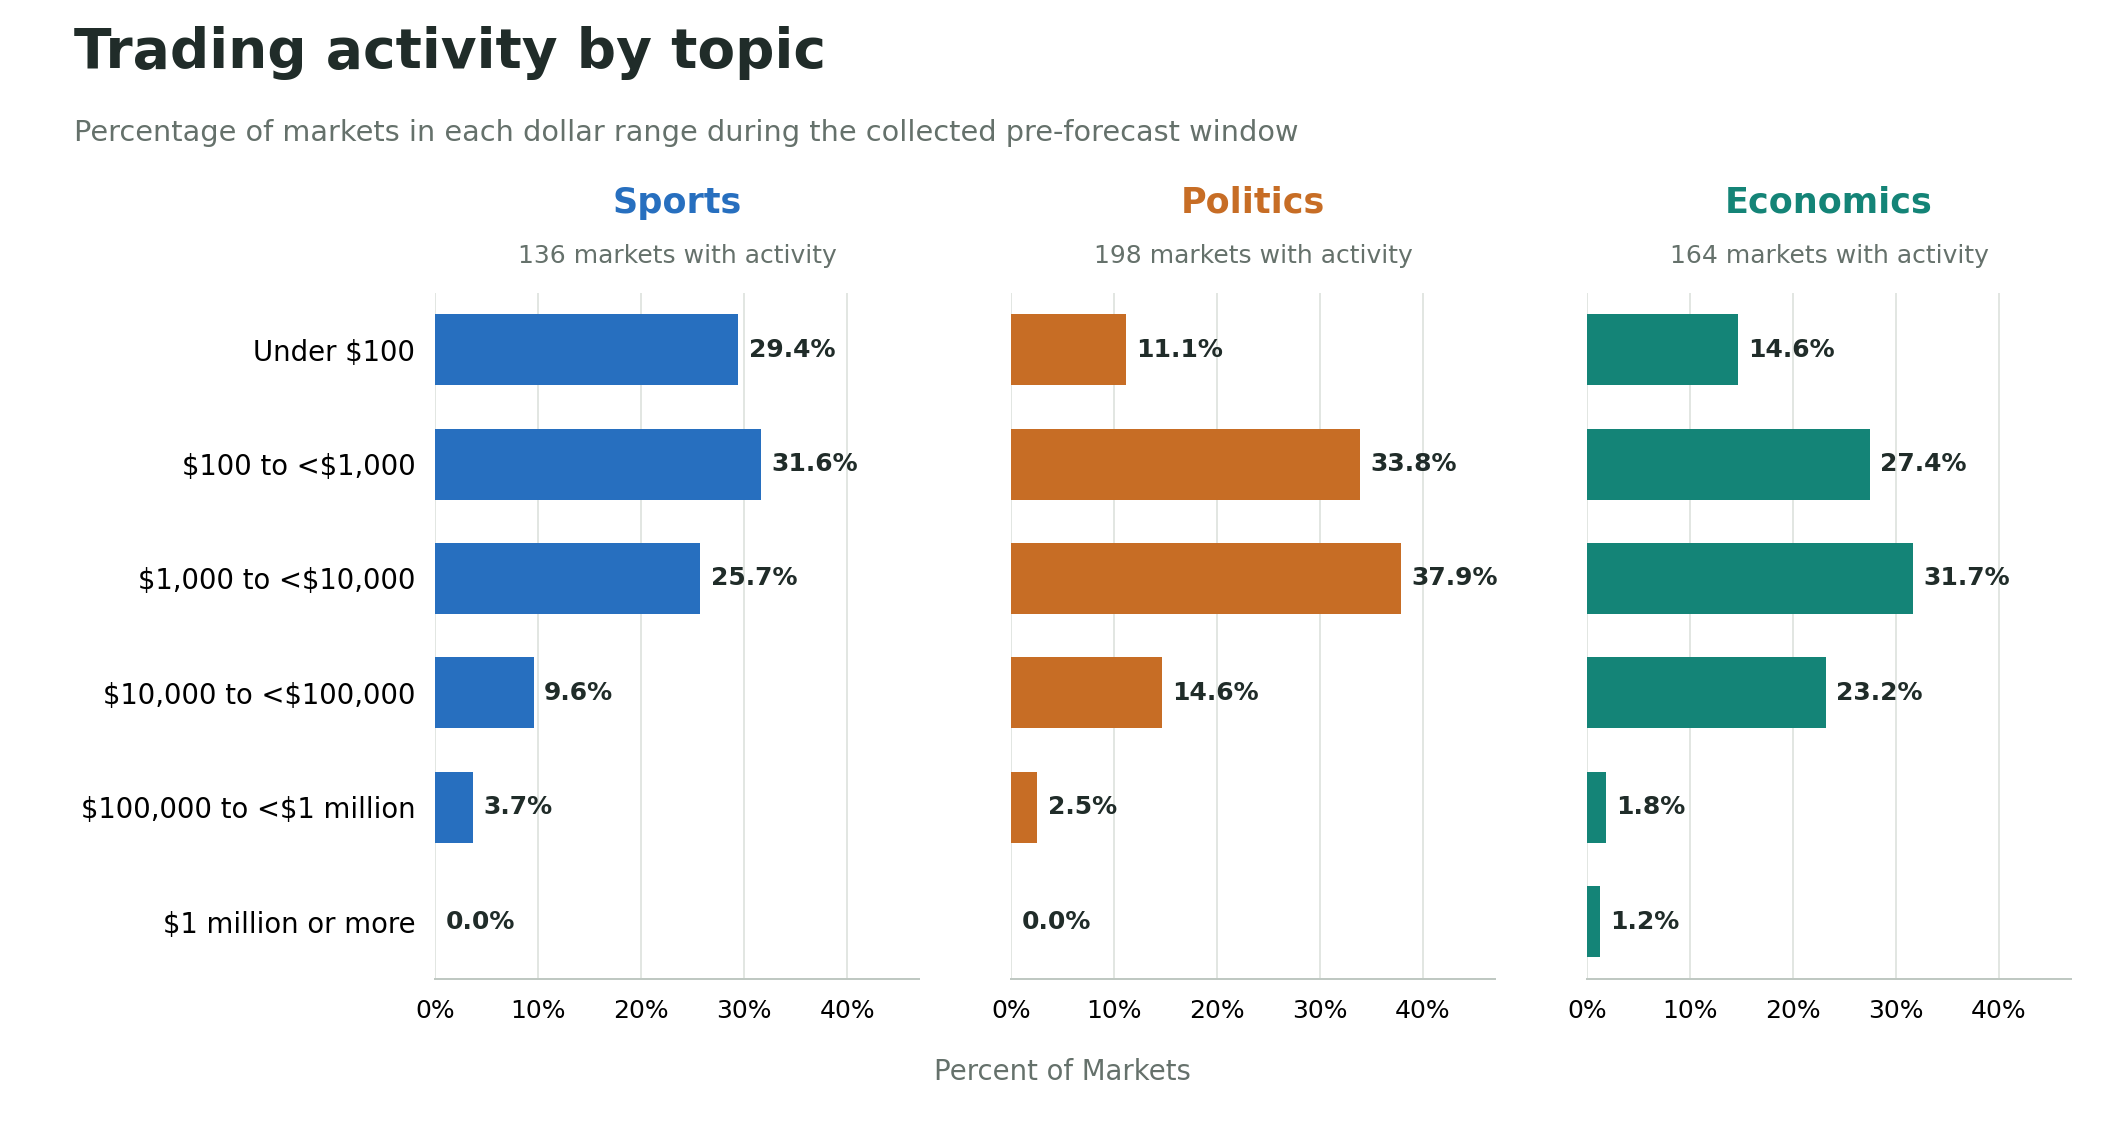

In [8]:
# Website source figure 07: complete calculations and rendering code.
def render_website_figure_07():
    """Readable, descriptive activity distribution for website Figure 07.

    Uses the final frozen v2 cohort. Positive-activity markets are counted once in
    explicit dollar bins; percentages use each topic's positive-activity count.
    No normalization of the underlying observations or model fitting is performed.
    """
    import csv
    import hashlib
    import json
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.ticker import PercentFormatter
    import numpy as np
    import pandas as pd

    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    DATA = ROOT / 'data/eda/20260916_v2'
    OUTPUT = ROOT / 'figures/eda_20260917_activity_distribution'
    TOPICS = ['Sports', 'Politics', 'Economics']
    COLORS = {'Sports':'#276FBF', 'Politics':'#C76D25', 'Economics':'#148477'}
    STEM = '07_account_activity'
    BIN_EDGES = [0, 100, 1000, 10000, 100000, 1000000, float('inf')]
    BIN_LABELS = ['Under $100', '$100 to <$1,000', '$1,000 to <$10,000',
                  '$10,000 to <$100,000', '$100,000 to <$1 million', '$1 million or more']


    def build_data():
        path = DATA / 'markets.csv'
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        manifest = json.loads((DATA/'manifest.json').read_text(encoding='utf-8'))
        assert digest == manifest['output_sha256']['markets.csv']
        markets = pd.read_csv(path, dtype={'market_id':str})
        assert len(markets) == markets.market_id.nunique() == 565
        assert markets.gross_account_activity.notna().all()
        assert (markets.gross_account_activity >= 0).all()
        assert markets.event_family_id.nunique() == 565
        positive = markets[markets.gross_account_activity > 0].copy()
        positive['activity_range'] = pd.cut(positive.gross_account_activity, BIN_EDGES,
                                            labels=BIN_LABELS, right=False, include_lowest=True)
        assert positive.activity_range.notna().all()
        rows, topic_stats = [], {}
        for topic in TOPICS:
            values = positive.loc[positive.topic == topic, 'gross_account_activity']
            counts = positive.loc[positive.topic == topic, 'activity_range'].value_counts(sort=False)
            n = len(values)
            assert int(counts.sum()) == n
            for index, label in enumerate(BIN_LABELS):
                count = int(counts[label])
                # Independent interval check, including exact lower/upper boundaries.
                assert count == int(((values >= BIN_EDGES[index]) & (values < BIN_EDGES[index+1])).sum())
                rows.append(dict(topic=topic, activity_range=label, range_lower_inclusive=BIN_EDGES[index],
                                 range_upper_exclusive=BIN_EDGES[index+1] if index<5 else '',
                                 market_count=count, positive_activity_markets=n,
                                 share_of_positive_markets=count/n))
            topic_stats[topic] = dict(total_markets=int((markets.topic == topic).sum()),
                                      positive_activity_markets=n,
                                      zero_activity_markets=int(((markets.topic == topic)&(markets.gross_account_activity == 0)).sum()),
                                      median_activity=float(values.median()),
                                      under_1000_count=int((values < 1000).sum()),
                                      under_1000_pct=float(100*(values < 1000).mean()))
        assert len(positive) == 498
        assert sum(s['zero_activity_markets'] for s in topic_stats.values()) == 67
        return pd.DataFrame(rows), positive, topic_stats, digest


    def draw(chart, stats):
        plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':11,
                             'svg.fonttype':'none', 'text.parse_math':False})
        fig, axes = plt.subplots(1, 3, figsize=(11.8, 6.25), sharex=True, sharey=True)
        fig.patch.set_facecolor('white')
        fig.subplots_adjust(left=.205, right=.975, top=.74, bottom=.13, wspace=.19)
        ink, muted = '#202C29', '#65716B'
        fig.text(.035, .94, 'Trading activity by topic', fontsize=22, weight='bold', color=ink)
        fig.text(.035, .875, 'Percentage of markets in each dollar range during the collected pre-forecast window', fontsize=11.5, color=muted)
        y = np.arange(len(BIN_LABELS))
        for ax, topic in zip(axes, TOPICS):
            rows = chart[chart.topic == topic]
            stats_row = stats[topic]
            ax.barh(y, rows.share_of_positive_markets, height=.62, color=COLORS[topic])
            ax.set_title(topic, fontsize=14, weight='bold', color=COLORS[topic], pad=32)
            ax.text(.5, 1.035, f"{stats_row['positive_activity_markets']} markets with activity",
                    transform=ax.transAxes, ha='center', va='bottom', color=muted, fontsize=10)
            ax.set(xlim=(0,.47), xticks=[0,.1,.2,.3,.4], ylim=(len(BIN_LABELS)-.5,-.5))
            ax.xaxis.set_major_formatter(PercentFormatter(1,decimals=0))
            ax.set_axisbelow(True)
            ax.grid(axis='x',color='#E2E6E2',lw=.8)
            for spine in ['top','right','left']:
                ax.spines[spine].set_visible(False)
            ax.spines['bottom'].set_color('#BFC8C2')
            ax.tick_params(axis='both',length=0,pad=8,labelsize=10,color=muted)
            for pos, row in zip(y, rows.itertuples()):
                ax.text(row.share_of_positive_markets+.010,pos,f'{100*row.share_of_positive_markets:.1f}%',
                        va='center',fontsize=10,weight='bold',color=ink)
        axes[0].set_yticks(y,BIN_LABELS,fontsize=11)
        # This is an axis label, not an explanatory footer note.
        fig.supxlabel('Percent of Markets',fontsize=11,color=muted,y=.035)
        return fig


    def main():
        chart, market_rows, stats, digest = build_data()
        OUTPUT.mkdir(parents=True,exist_ok=True)
        chart.to_csv(OUTPUT/'activity_ranges.csv',index=False)
        market_rows[['market_id','topic','gross_account_activity','window_hours','activity_range']].to_csv(
            OUTPUT/'market_activity.csv',index=False)
        fig=draw(chart,stats)
        fig.savefig(OUTPUT/f'{STEM}.png',dpi=180)
        fig.savefig(OUTPUT/f'{STEM}.svg')
        plt.close(fig)
        caption = (
            f"Each bar shows the percentage of markets in that topic whose recorded trading activity fell in the dollar range. "
            f"Among markets with activity, {stats['Sports']['under_1000_pct']:.0f}% of Sports markets recorded less than $1,000, "
            f"compared with {stats['Politics']['under_1000_pct']:.0f}% of Politics and {stats['Economics']['under_1000_pct']:.0f}% of Economics markets. "
            "The 67 markets without recorded activity were omitted, leaving 498 of the final 565 markets in this chart. "
            "Activity is the sum of price multiplied by share size across returned account records, including both sides of transactions. "
            "It covers up to seven days ending at the forecast cutoff; shorter windows have less time to accumulate activity. "
            "These are account-level totals, not reconciled exchange turnover, and the chart does not assess forecast accuracy."
        )
        alt = ('Three aligned bar charts show the share of markets in six dollar ranges by topic. '
               '61% of Sports markets with activity fall below $1000, compared with 45% of Politics and 42% of Economics. '
               'Denominators are 136 Sports, 198 Politics and 164 Economics markets; zero-activity windows are omitted.')
        metadata = dict(title='Trading activity by topic',caption=caption,alt=alt,
                        source='data/eda/20260916_v2/markets.csv',source_sha256=digest,
                        cohort_markets=565,included_markets=498,omitted_zero_activity_markets=67,
                        denominator='Each topic\'s markets with gross_account_activity > 0',
                        bin_rule='Lower-inclusive, upper-exclusive; final bin is $1 million or more. First bin excludes zero.',
                        topic_stats=stats,checks_passed=True,normalization='Percentages for display only; source amounts unchanged')
        (OUTPUT/'metadata.json').write_text(json.dumps(metadata,indent=2)+'\n',encoding='utf-8')
        (OUTPUT/'README.md').write_text('# Trading activity by topic\n\n'+caption+'\n\n'
            'The bars show how many markets fall within explicit dollar ranges. Broad bins conceal variation '
            'within each range; exact amounts are retained in the market-level export.\n\n'
            '[PNG](07_account_activity.png) | [SVG](07_account_activity.svg) | [Chart data](activity_ranges.csv) | '
            '[Market-level data](market_activity.csv) | [Definitions and checks](metadata.json)\n\n'
            'Rebuild with `python -X utf8 -B src/render_activity_distribution.py`.\n',encoding='utf-8')
        print(json.dumps(stats,indent=2))


    main()

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_07()

# Register the current figure in the notebook gallery and show its actual output.
from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_activity_distribution'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('07_account_activity.' + extension), FIGURES / ('07_account_activity.' + extension))
shutil.copy2(figure_output / 'activity_ranges.csv', FIGURES / 'chart_data/07_account_activity.csv')
visuals.append(dict(id='07_account_activity', title=figure_details.get('title', 'Market pool, replacements and final cohort'),
                    caption=figure_details['caption'], source='Complete calculation code in this notebook cell', footer='',
                    png='07_account_activity.png', svg='07_account_activity.svg', data='chart_data/07_account_activity.csv'))
display(Image(filename=str(figure_output / '07_account_activity.png')))


{
  "Sports": {
    "total_markets": 200,
    "plotted_markets": 136,
    "zero_wallet_windows": 64,
    "min": 2,
    "median": 13.0,
    "max": 804,
    "captured_density_area": 0.9999999999999101
  },
  "Politics": {
    "total_markets": 200,
    "plotted_markets": 198,
    "zero_wallet_windows": 2,
    "min": 2,
    "median": 33.0,
    "max": 917,
    "captured_density_area": 0.9999999999990349
  },
  "Economics": {
    "total_markets": 165,
    "plotted_markets": 164,
    "zero_wallet_windows": 1,
    "min": 2,
    "median": 42.0,
    "max": 3112,
    "captured_density_area": 0.9999939351877779
  }
}


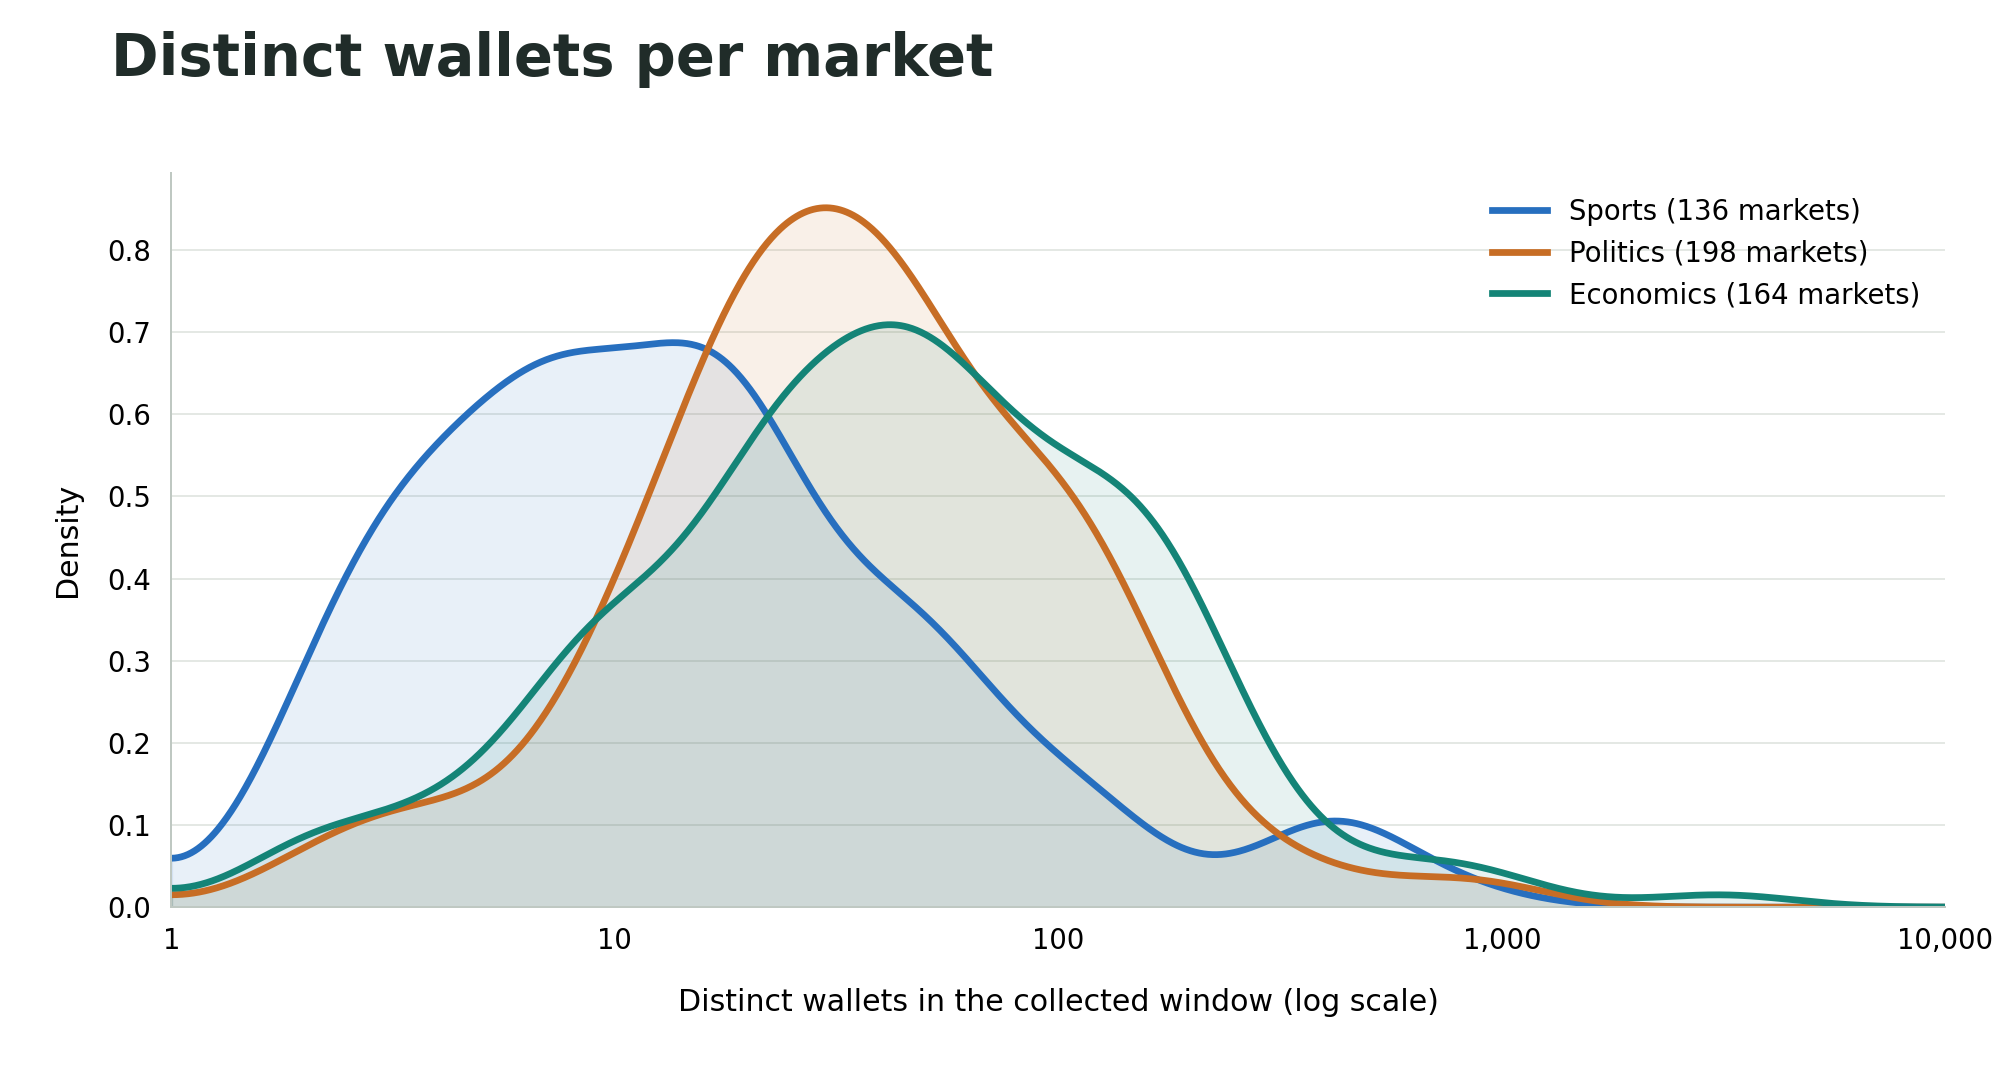

In [9]:
# Website source figure 08: complete calculations and rendering code.
def render_website_figure_08():
    """Website Figure 08: distinct observed wallets per market, by topic.

    Each market contributes once. Gaussian density estimates use log10 wallet
    counts, a common pooled Scott bandwidth, and reflection at zero in log space.
    Zero-wallet windows are reported separately, not shifted to invented counts.
    Only display calculations are transformed; the source data are unchanged.
    """
    import hashlib
    import json
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    import numpy as np
    import pandas as pd

    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    DATA = ROOT / 'data/eda/20260916_v2'
    OUTPUT = ROOT / 'figures/eda_20260917_wallet_density'
    TOPICS = ['Sports', 'Politics', 'Economics']
    COLORS = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    STEM = '08_wallet_density'


    def build_data():
        path = DATA / 'markets.csv'
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        manifest = json.loads((DATA / 'manifest.json').read_text(encoding='utf-8'))
        assert digest == manifest['output_sha256']['markets.csv']
        markets = pd.read_csv(path, dtype={'market_id': str})
        assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
        counts = markets.observed_wallet_count
        assert counts.notna().all() and counts.ge(0).all() and counts.mod(1).eq(0).all()
        assert counts.eq(0).equals(markets.zero_returned_trades)
        # Confirm the market summary against distinct addresses in the prepared trades.
        trades = pd.read_csv(DATA / 'trades.csv.gz', usecols=['market_id', 'wallet_address'], dtype=str)
        assert set(trades.market_id).issubset(set(markets.market_id))
        distinct = trades.groupby('market_id').wallet_address.nunique()
        recomputed = markets.market_id.map(distinct).fillna(0).astype(int)
        assert np.array_equal(recomputed.to_numpy(), counts.to_numpy())
        positive = markets[counts > 0].copy()
        assert len(positive) == 498
        pooled = np.log10(positive.observed_wallet_count.to_numpy())
        bandwidth = float(pooled.std(ddof=1) * len(pooled) ** (-1 / 5))
        grid = np.linspace(0, 4, 1601)
        assert positive.observed_wallet_count.max() <= 10 ** grid[-1]
        rows, stats = [], {}
        for topic in TOPICS:
            all_values = markets.loc[markets.topic.eq(topic), 'observed_wallet_count']
            values = all_values[all_values > 0].to_numpy()
            log_values = np.log10(values)
            distances = (grid[:, None] - log_values[None, :]) / bandwidth
            reflected = (grid[:, None] + log_values[None, :]) / bandwidth
            density = (np.exp(-.5 * distances ** 2) + np.exp(-.5 * reflected ** 2)).mean(axis=1)
            density /= bandwidth * np.sqrt(2 * np.pi)
            captured_area = float(np.trapezoid(density, grid))
            assert abs(captured_area - 1) < 1e-5
            # Normalize over the displayed support after negligible tail truncation.
            density /= captured_area
            assert np.isfinite(density).all() and (density >= 0).all()
            assert abs(np.trapezoid(density, grid) - 1) < 1e-12
            rows.extend(dict(topic=topic, log10_wallet_count=float(x), wallet_count=float(10 ** x),
                             density_per_log10_wallet_count=float(y)) for x, y in zip(grid, density))
            stats[topic] = dict(total_markets=len(all_values), plotted_markets=len(values),
                                zero_wallet_windows=int((all_values == 0).sum()),
                                min=int(values.min()), median=float(np.median(values)), max=int(values.max()),
                                captured_density_area=captured_area)
        return markets, pd.DataFrame(rows), stats, bandwidth, digest


    def draw(curves, stats):
        plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'svg.fonttype': 'none'})
        fig, ax = plt.subplots(figsize=(11.2, 6.0))
        fig.patch.set_facecolor('white')
        fig.subplots_adjust(left=.085, right=.965, top=.84, bottom=.16)
        fig.text(.055, .93, 'Distinct wallets per market', fontsize=23, weight='bold', color='#202C29')
        for topic in TOPICS:
            rows = curves[curves.topic.eq(topic)]
            ax.fill_between(rows.wallet_count, rows.density_per_log10_wallet_count, color=COLORS[topic], alpha=.10)
            ax.plot(rows.wallet_count, rows.density_per_log10_wallet_count, color=COLORS[topic], lw=2.7,
                    label=f"{topic} ({stats[topic]['plotted_markets']} markets)")
        ax.set_xscale('log')
        ax.set_xlim(1, 10000)
        ax.set_ylim(bottom=0)
        ax.xaxis.set_major_locator(FixedLocator([1, 10, 100, 1000, 10000]))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xlabel('Distinct wallets in the collected window (log scale)', labelpad=13)
        ax.set_ylabel('Density', labelpad=10)
        ax.grid(axis='y', color='#E4E8E4', lw=.8)
        ax.set_axisbelow(True)
        ax.legend(frameon=False, loc='upper right', fontsize=11)
        for side in ['top', 'right']:
            ax.spines[side].set_visible(False)
        for side in ['left', 'bottom']:
            ax.spines[side].set_color('#BFC8C2')
        ax.tick_params(length=0, pad=8, labelsize=11)
        return fig


    def main():
        markets, curves, stats, bandwidth, digest = build_data()
        OUTPUT.mkdir(parents=True, exist_ok=True)
        curves.to_csv(OUTPUT / 'wallet_density.csv', index=False)
        markets[['market_id', 'topic', 'observed_wallet_count', 'window_hours', 'zero_returned_trades']].to_csv(
            OUTPUT / 'market_wallet_counts.csv', index=False)
        fig = draw(curves, stats)
        fig.savefig(OUTPUT / f'{STEM}.png', dpi=180)
        fig.savefig(OUTPUT / f'{STEM}.svg')
        plt.close(fig)
        caption = (
            'The curves show how distinct wallet counts vary across markets in each topic; higher parts indicate more common counts. '
            'Each market contributes once, using addresses found in both BUY and SELL records during its collected window '
            'of up to seven days before the forecast cutoff. The curves include 498 markets from the final 565-market sample. '
            'The 67 windows with no returned trades (64 Sports, 2 Politics and 1 Economics) have zero observed wallets and are omitted from these curves. '
            'Counts are smoothed on a logarithmic scale, with equal area for each topic. Wallets represent addresses, not necessarily different people; '
            'shorter collection windows offer less time to observe participants.'
        )
        alt = ('Density curves for distinct wallet counts per market, with a logarithmic x-axis. '
               'Includes 136 Sports, 198 Politics and 164 Economics markets with observed wallets. '
               'Median counts among these markets are 13, 33 and 42 respectively. Zero-wallet windows are omitted.')
        metadata = dict(title='Distinct wallets per market', caption=caption, alt=alt,
                        source='data/eda/20260916_v2/markets.csv', source_sha256=digest,
                        field='observed_wallet_count', included_markets=498, zero_wallet_windows=67,
                        source_cohort_markets=565, topic_stats=stats, checks_passed=True,
                        estimator='Gaussian KDE in log10(count), common pooled Scott bandwidth, reflected at log10(count)=0',
                        bandwidth_log10_units=bandwidth, displayed_support_wallets=[1, 10000],
                        area_definition='Integral with respect to log10(wallet count) is 1 per topic; not density per raw wallet.',
                        boundary_and_tail_rule='Reflect at one wallet; normalize negligible tail truncation above 10000. No zero count is shifted.',
                        independent_verification='All 565 market wallet counts match distinct wallet_address values in prepared trades.csv.gz')
        (OUTPUT / 'metadata.json').write_text(json.dumps(metadata, indent=2) + '\n', encoding='utf-8')
        (OUTPUT / 'README.md').write_text(
            '# Distinct wallets per market\n\n' + caption + '\n\n'
            'The final 565-market sample supplies 498 positive wallet counts; 67 zero-wallet windows are omitted.\n\n'
            'A common pooled Scott bandwidth is used for all topics so the amount of smoothing is comparable. '
            'The estimate is calculated with Gaussian kernels in log10 wallet-count space, reflected at zero in that space '
            '(one wallet). Equal areas describe within-topic distributions, not the relative sample sizes. '
            'Wallet counts are discrete; this smooth display does not imply fractional observed wallets. '
            'No source counts are transformed or imputed.\n\n'
            '[PNG](08_wallet_density.png) | [SVG](08_wallet_density.svg) | [Market-level counts](market_wallet_counts.csv) | '
            '[Curve data](wallet_density.csv) | [Definitions and checks](metadata.json)\n\n'
            'Rebuild with `python -X utf8 -B src/render_wallet_density.py`.\n', encoding='utf-8')
        print(json.dumps(stats, indent=2))


    main()

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_08()

# Register the current figure in the notebook gallery and show its actual output.
from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_wallet_density'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('08_wallet_density.' + extension), FIGURES / ('08_wallets_activity.' + extension))
shutil.copy2(figure_output / 'market_wallet_counts.csv', FIGURES / 'chart_data/08_wallets_activity.csv')
visuals.append(dict(id='08_wallets_activity', title=figure_details.get('title', 'Market pool, replacements and final cohort'),
                    caption=figure_details['caption'], source='Complete calculation code in this notebook cell', footer='',
                    png='08_wallets_activity.png', svg='08_wallets_activity.svg', data='chart_data/08_wallets_activity.csv'))
display(Image(filename=str(figure_output / '08_wallet_density.png')))


### Wallets shared across topics

Website Figure 09 counts addresses observed in multiple sampled topics. Each address counts once per topic, and each topic has its own denominator. The result describes participation within the collected windows, not lifetime specialization or distinct people.


    topic  total_wallets  only_this_topic  also_other_topics  shared_percent
   Sports           5009             4718                291        5.809543
 Politics           7536             6127               1409       18.696921
Economics          11337             9969               1368       12.066684
Economics                        9969
Politics                         6127
Sports                           4718
Politics + Economics             1186
Sports + Politics + Economics     114
Sports + Politics                 109
Sports + Economics                 68


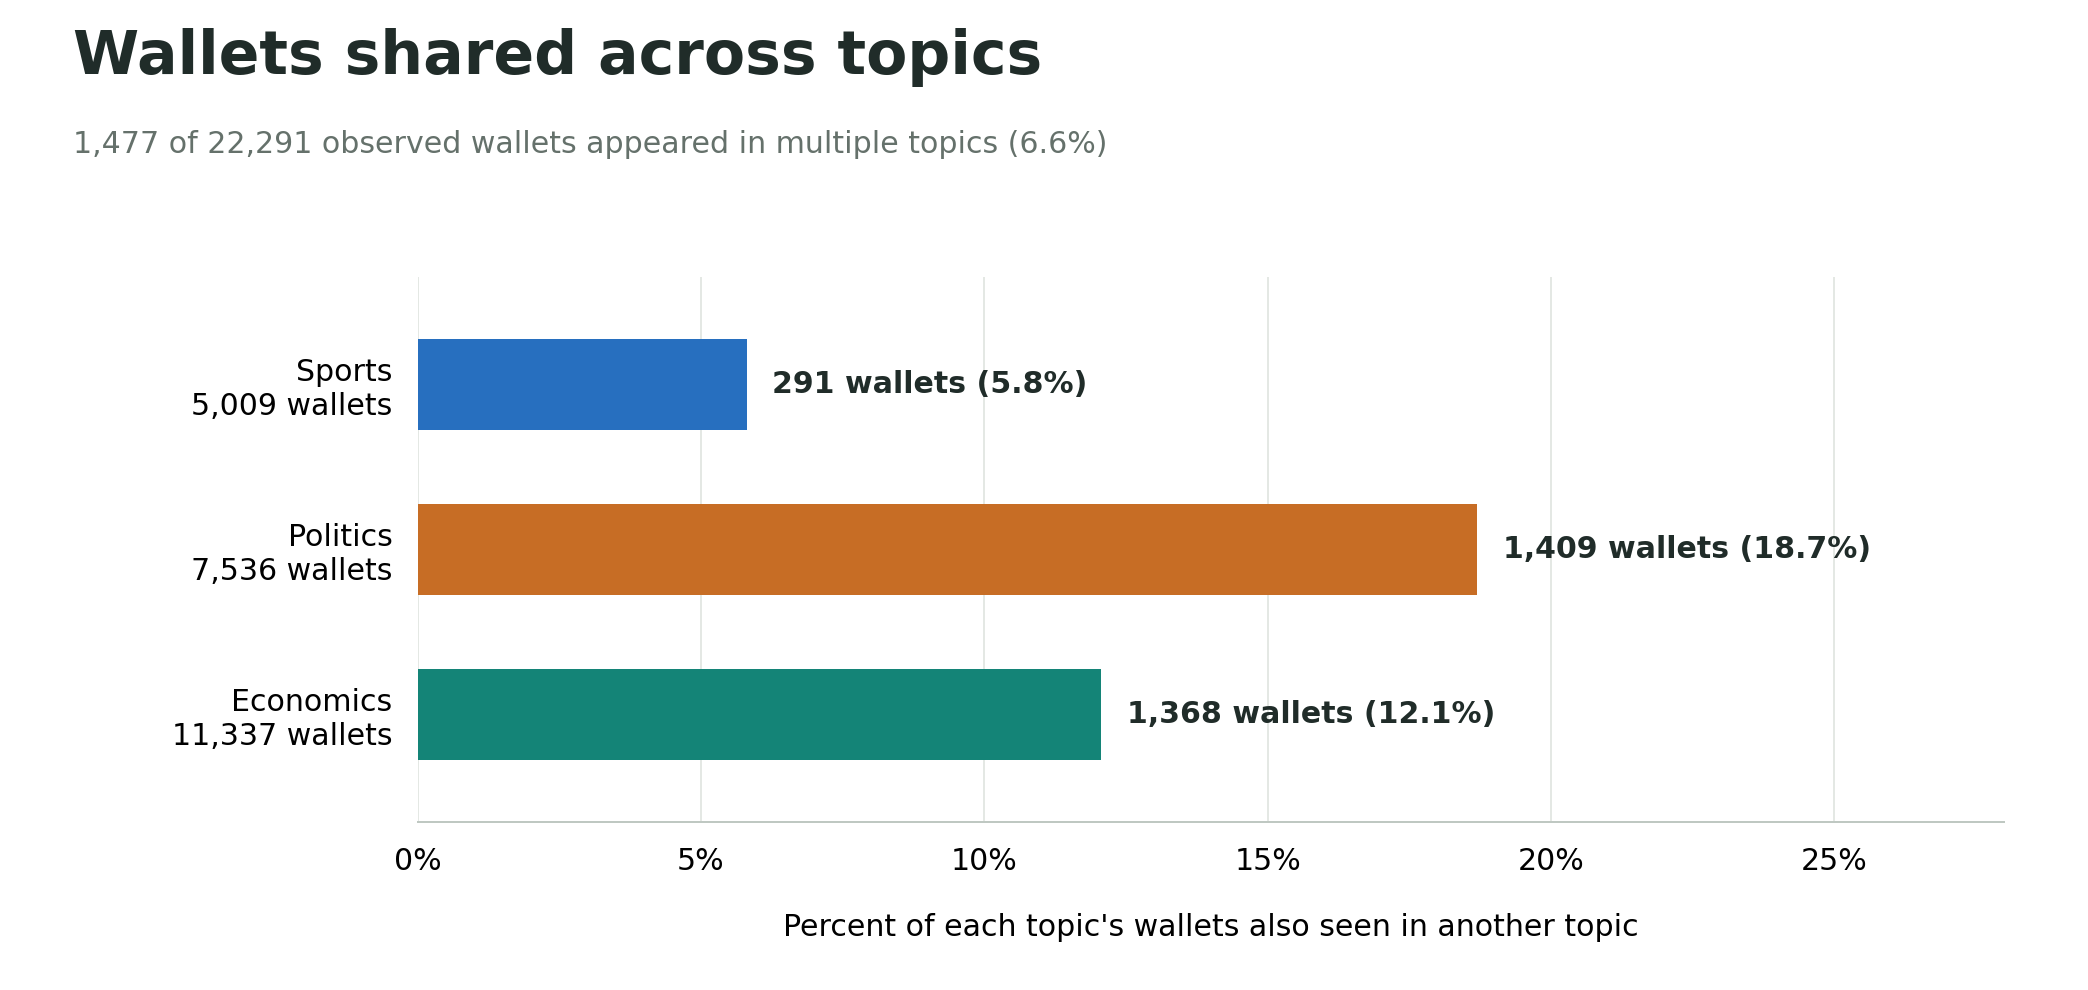

In [10]:
# Website source figure 11 (displayed Figure 09): wallets shared across topics.
def render_website_figure_11():
    from pathlib import Path
    import hashlib, json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import PercentFormatter

    root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    data = root / 'data/eda/20260916_v2'
    output = root / 'figures/eda_20260917_wallet_overlap'
    output.mkdir(parents=True, exist_ok=True)
    topics = ['Sports', 'Politics', 'Economics']
    colors = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    manifest = json.loads((data / 'manifest.json').read_text(encoding='utf-8'))
    hashes = {}
    for name in ['markets.parquet', 'trades.parquet']:
        hashes[name] = hashlib.sha256((data / name).read_bytes()).hexdigest()
        assert hashes[name] == manifest['output_sha256'][name]
    markets = pd.read_parquet(data / 'markets.parquet')
    trades = pd.read_parquet(data / 'trades.parquet')
    assert len(markets) == markets.market_id.nunique() == 565
    assert len(trades) == trades.trade_row_id.nunique() == 155177
    assert trades.wallet_address.notna().all()
    assert trades.wallet_address.str.fullmatch(r'0x[0-9a-f]{40}').all()
    trades = trades.merge(markets[['market_id', 'topic', 'window_start_utc', 'forecast_cutoff_utc']],
                          on='market_id', validate='many_to_one')
    assert len(trades) == 155177 and trades.topic.isin(topics).all()
    assert trades.trade_time_utc.ge(trades.window_start_utc).all()
    assert trades.trade_time_utc.le(trades.forecast_cutoff_utc).all()

    # Presence is based on at least one returned BUY or SELL record, in either
    # outcome. Repeated rows and repeated visits to a topic cannot increase it.
    assert set(trades.side.unique()) == {'BUY', 'SELL'}
    presence = trades[['wallet_address', 'topic']].drop_duplicates()
    membership = pd.crosstab(presence.wallet_address, presence.topic).reindex(columns=topics, fill_value=0).astype(bool)
    topic_count = membership.sum(axis=1)
    assert len(membership) == trades.wallet_address.nunique() == 22291
    assert topic_count.between(1, 3).all()
    one = int(topic_count.eq(1).sum())
    two = int(topic_count.eq(2).sum())
    three = int(topic_count.eq(3).sum())
    multi = two + three
    assert [one, two, three] == [20814, 1363, 114]
    chart = pd.DataFrame([
        dict(topic=t, total_wallets=int(membership[t].sum()),
             only_this_topic=int((membership[t] & topic_count.eq(1)).sum()),
             also_other_topics=int((membership[t] & topic_count.gt(1)).sum())) for t in topics])
    chart['shared_percent'] = 100 * chart.also_other_topics / chart.total_wallets
    assert (chart.only_this_topic + chart.also_other_topics).equals(chart.total_wallets)
    assert chart.also_other_topics.tolist() == [291, 1409, 1368]
    assert chart.also_other_topics.sum() == 2 * two + 3 * three
    assert chart.only_this_topic.sum() == one

    # Independent set intersections verify inclusive pair counts and bar totals.
    sets = {t: set(presence.loc[presence.topic.eq(t), 'wallet_address']) for t in topics}
    pairs = []
    for i, left in enumerate(topics):
        for right in topics[i + 1:]:
            pair = len(sets[left] & sets[right])
            pairs.append(dict(topic_1=left, topic_2=right, shared_wallets_including_all_three=pair,
                              shared_wallets_only_these_two=pair - three))
    assert len(set.union(*sets.values())) == len(membership)
    for row in chart.itertuples():
        elsewhere = set.union(*(sets[t] for t in topics if t != row.topic))
        assert len(sets[row.topic] & elsewhere) == row.also_other_topics
    assert len(set.intersection(*sets.values())) == three
    exact = membership.apply(lambda row: ' + '.join(t for t in topics if row[t]), axis=1).value_counts()
    assert len(exact) == 7 and exact.sum() == len(membership)

    # Exact-repeat sensitivity leaves wallet presence unchanged.
    without_repeats = trades.loc[~trades.duplicate_excess, ['wallet_address', 'topic']].drop_duplicates()
    assert set(map(tuple, without_repeats.to_numpy())) == set(map(tuple, presence.to_numpy()))
    per_market = trades.groupby('market_id').agg(observed_wallets=('wallet_address', 'nunique'),
                                                mean_shares=('size', 'mean'), mean_dollars=('row_notional', 'mean'))
    joined = markets.set_index('market_id').join(per_market)
    assert np.array_equal(joined.observed_wallet_count.to_numpy(), joined.observed_wallets.fillna(0).to_numpy())
    active = joined[joined.observed_wallets.gt(0)]
    assert len(active) == 498
    assert np.allclose(active.mean_shares.astype(float), active.mean_trade_row_size.astype(float))
    assert np.allclose(active.mean_dollars.astype(float), active.mean_trade_row_notional.astype(float))
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12, 'svg.fonttype': 'none', 'text.parse_math': False})
    fig, ax = plt.subplots(figsize=(11.6, 5.5))
    fig.patch.set_facecolor('white')
    fig.subplots_adjust(left=.20, right=.96, top=.72, bottom=.17)
    fig.text(.035, .925, 'Wallets shared across topics', fontsize=24, weight='bold', color='#202C29')
    fig.text(.035, .845, f'{multi:,} of {len(membership):,} observed wallets appeared in multiple topics ({100 * multi / len(membership):.1f}%)',
             fontsize=12, color='#65716B')
    y = np.arange(len(topics))
    ax.barh(y, chart.shared_percent, color=[colors[t] for t in topics], height=.55)
    for pos, row in enumerate(chart.itertuples()):
        ax.text(row.shared_percent + .45, pos, f'{row.also_other_topics:,} wallets ({row.shared_percent:.1f}%)',
                va='center', fontsize=12, weight='bold', color='#202C29')
    ax.set_yticks(y, [f'{r.topic}\n{r.total_wallets:,} wallets' for r in chart.itertuples()])
    ax.set_ylim(2.65, -.65)
    ax.set_xlim(0, 28)
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
    ax.set_xlabel("Percent of each topic's wallets also seen in another topic", labelpad=15)
    ax.grid(axis='x', color='#E4E8E4', linewidth=.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=10)
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#BFC8C2')
    fig.savefig(output / '11_wallet_overlap.png', dpi=180)
    fig.savefig(output / '11_wallet_overlap.svg')
    plt.close(fig)

    caption = (
        'Bars show the percentage of each topic\'s observed wallet addresses also found in at least one other topic. '
        'Across the sample, 20,814 addresses appear in one topic, 1,363 in two and 114 in all three. '
        'Politics has the highest shared-wallet percentage (18.7%); the largest pairwise overlap is Politics and Economics, '
        'with 1,300 shared addresses including those seen in all three. An address can contribute to more than one bar. '
        'Counts use both BUY and SELL records within the sampled markets\' collected pre-cutoff windows. '
        'They do not describe complete trading histories or prove that single-topic wallets specialize; addresses are not necessarily distinct people.'
    )
    alt = ('Horizontal bars showing wallets also seen in another topic: Sports 291 of 5009 (5.8%), '
           'Politics 1409 of 7536 (18.7%), Economics 1368 of 11337 (12.1%). '
           'Overall 1477 of 22291 unique addresses appear in multiple topics (6.6%).')
    details = dict(title='Wallets shared across topics', caption=caption, alt=alt,
                   markets=len(markets), trade_records=len(trades), unique_wallets=len(membership),
                   one_topic=one, two_topics=two, three_topics=three, multiple_topics=multi,
                   multiple_topics_percent=100 * multi / len(membership),
                   repeat_collapse_preserves_membership=True, checks_passed=True, input_sha256=hashes)
    chart.to_csv(output / 'topic_overlap.csv', index=False)
    pd.DataFrame(pairs).to_csv(output / 'pairwise_overlap.csv', index=False)
    exact.rename_axis('exact_topic_combination').rename('wallets').to_csv(output / 'exact_topic_combinations.csv')
    membership.assign(topic_count=topic_count).to_csv(output / 'wallet_topic_membership.csv')
    (output / 'metadata.json').write_text(json.dumps(details, indent=2) + '\n', encoding='utf-8')
    (output / 'README.md').write_text('# Wallets shared across topics\n\n' + caption + '\n\n'
        'Count each lowercased address once per observed topic. Membership uses all returned BUY and SELL rows, '
        'both outcomes, and retained repeated records. No wallet or trade is removed from the source tables. '
        'Each bar uses its own topic denominator: 5,009 Sports, 7,536 Politics and 11,337 Economics. '
        'The overall 6.6% uses the union of 22,291 addresses; topic totals and shared counts overlap and must not be summed as unique wallets. '
        'The 67 no-returned-trade windows contribute no observed addresses. Sample composition and unequal window durations affect which addresses can be seen.\n\n'
        'All seven exclusive topic combinations and the three inclusive pair counts are exported. '
        'Independent set intersections reconcile every bar, exact combinations exhaust the union, and collapsing exact repeats leaves membership unchanged. '
        'Per-market distinct-address counts match the prepared markets table; market/trade hashes match the frozen manifest.\n\n'
        'Complete calculation and rendering code is in notebook source cell 11 (displayed website Figure 09).\n', encoding='utf-8')
    print(chart.to_string(index=False))
    print(exact.to_string())

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_11()

from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_wallet_overlap'
figure_details = json.loads((figure_output / 'metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('11_wallet_overlap.' + extension), FIGURES / ('11_wallet_overlap.' + extension))
shutil.copy2(figure_output / 'topic_overlap.csv', FIGURES / 'chart_data/11_wallet_overlap.csv')
visuals.append(dict(id='11_wallet_overlap', title=figure_details['title'], caption=figure_details['caption'],
                    source='Complete calculation code in this notebook cell', footer='', png='11_wallet_overlap.png',
                    svg='11_wallet_overlap.svg', data='chart_data/11_wallet_overlap.csv'))
display(Image(filename=str(figure_output / '11_wallet_overlap.png')))


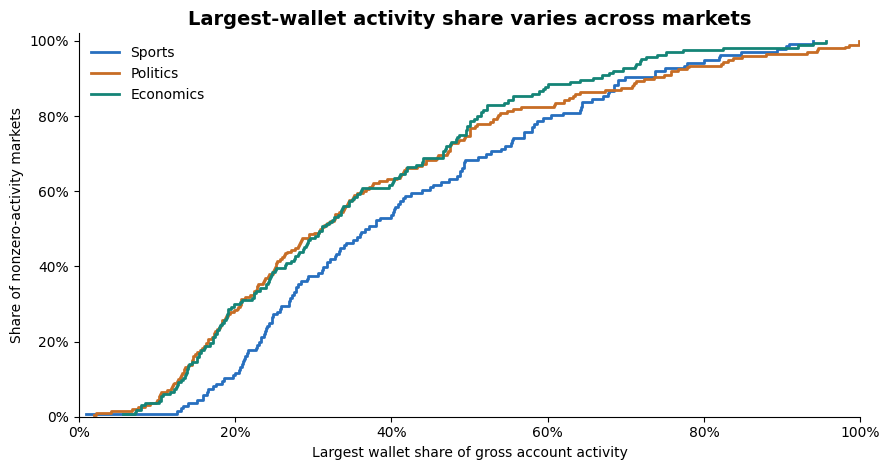

In [11]:
chart=markets[markets.top_wallet_activity_share.notna()][['market_id','topic','top_wallet_activity_share','wallet_activity_hhi']]
fig,ax=plt.subplots(figsize=(9,4.8))
for topic in TOPICS:
    subset=chart[chart.topic==topic];ecdf(ax,100*subset.top_wallet_activity_share.astype(float),color=COLORS[topic],label=topic,linewidth=2)
ax.set(title='Largest-wallet activity share varies across markets',xlabel='Largest wallet share of gross account activity',ylabel='Share of nonzero-activity markets',xlim=(0,100),ylim=(0,1.02))
ax.xaxis.set_major_formatter(PercentFormatter(100));ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(frameon=False)
save(fig,'09_wallet_concentration','Wallet activity concentration',
    'The measure assigns each observed wallet a share of the market’s summed account-row notional and plots the largest share. Concentration is undefined for the 67 windows with no returned trades, so those markets are not represented as zero concentration.',
    chart,'markets.top_wallet_activity_share, wallet_activity_hhi, topic',
    'Primary retained-row convention; this measures observed activity concentration, not ownership or person-level concentration.')

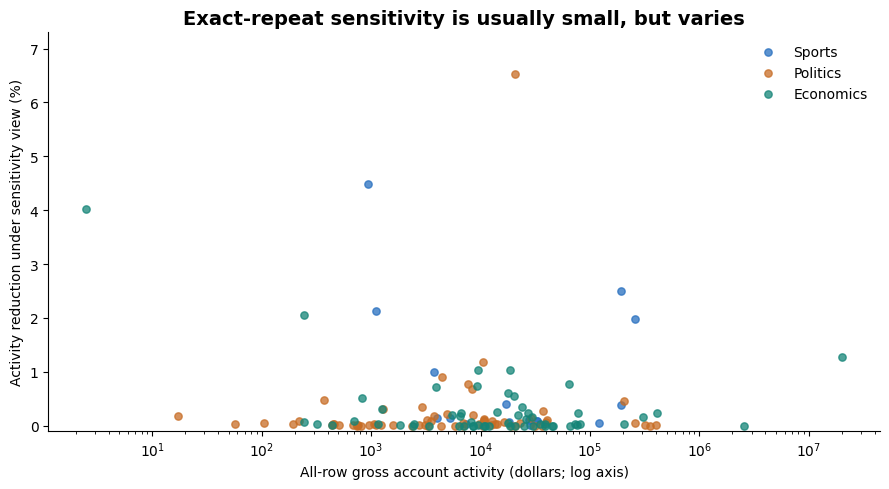

In [12]:
chart=markets[markets.exact_duplicate_excess>0][['market_id','topic','gross_account_activity','duplicate_activity_difference_pct','exact_duplicate_excess']]
fig,ax=plt.subplots(figsize=(9,5))
for topic in TOPICS:
    subset=chart[chart.topic==topic];ax.scatter(subset.gross_account_activity.astype(float),subset.duplicate_activity_difference_pct.astype(float),s=28,alpha=.75,color=COLORS[topic],label=topic)
ax.set(xscale='log',title='Exact-repeat sensitivity is usually small, but varies',xlabel='All-row gross account activity (dollars; log axis)',ylabel='Activity reduction under sensitivity view (%)',ylim=(-.1,7.3))
ax.legend(frameon=False)
save(fig,'10_duplicate_sensitivity','Sensitivity to exact repeated rows',
    f'The sensitivity view omits {int(markets.exact_duplicate_excess.sum()):,} excess exact repeated rows across {len(chart)} markets, reducing overall account activity by {100*(1-markets.sensitivity_account_activity.sum()/markets.gross_account_activity.sum()):.3f}%. The largest within-market reduction is {markets.duplicate_activity_difference_pct.max():.2f}%; the primary rows remain intact.',
    chart,'markets: all-row and exact-signature activity summaries',
    f'{len(chart)} affected markets shown; primary rows are retained. Repeated-looking records are not proven duplicate exchange fills.')

## 4. Observed price spacing and cutoff forecasts

The hourly request does not guarantee an exact grid. Adjacent probability differences are observed steps with measured elapsed times; no interpolation or forward fill has been applied. Internal price gaps and the age of the selected cutoff forecast are separate quantities.

{
  "hourly_snapshots": 557,
  "finer_snapshots": 8,
  "min_age_seconds": 9,
  "max_age_seconds": 21541,
  "finer_by_topic": {
    "Sports": 3,
    "Politics": 4,
    "Economics": 1
  },
  "hourly_path_matches": 557
}


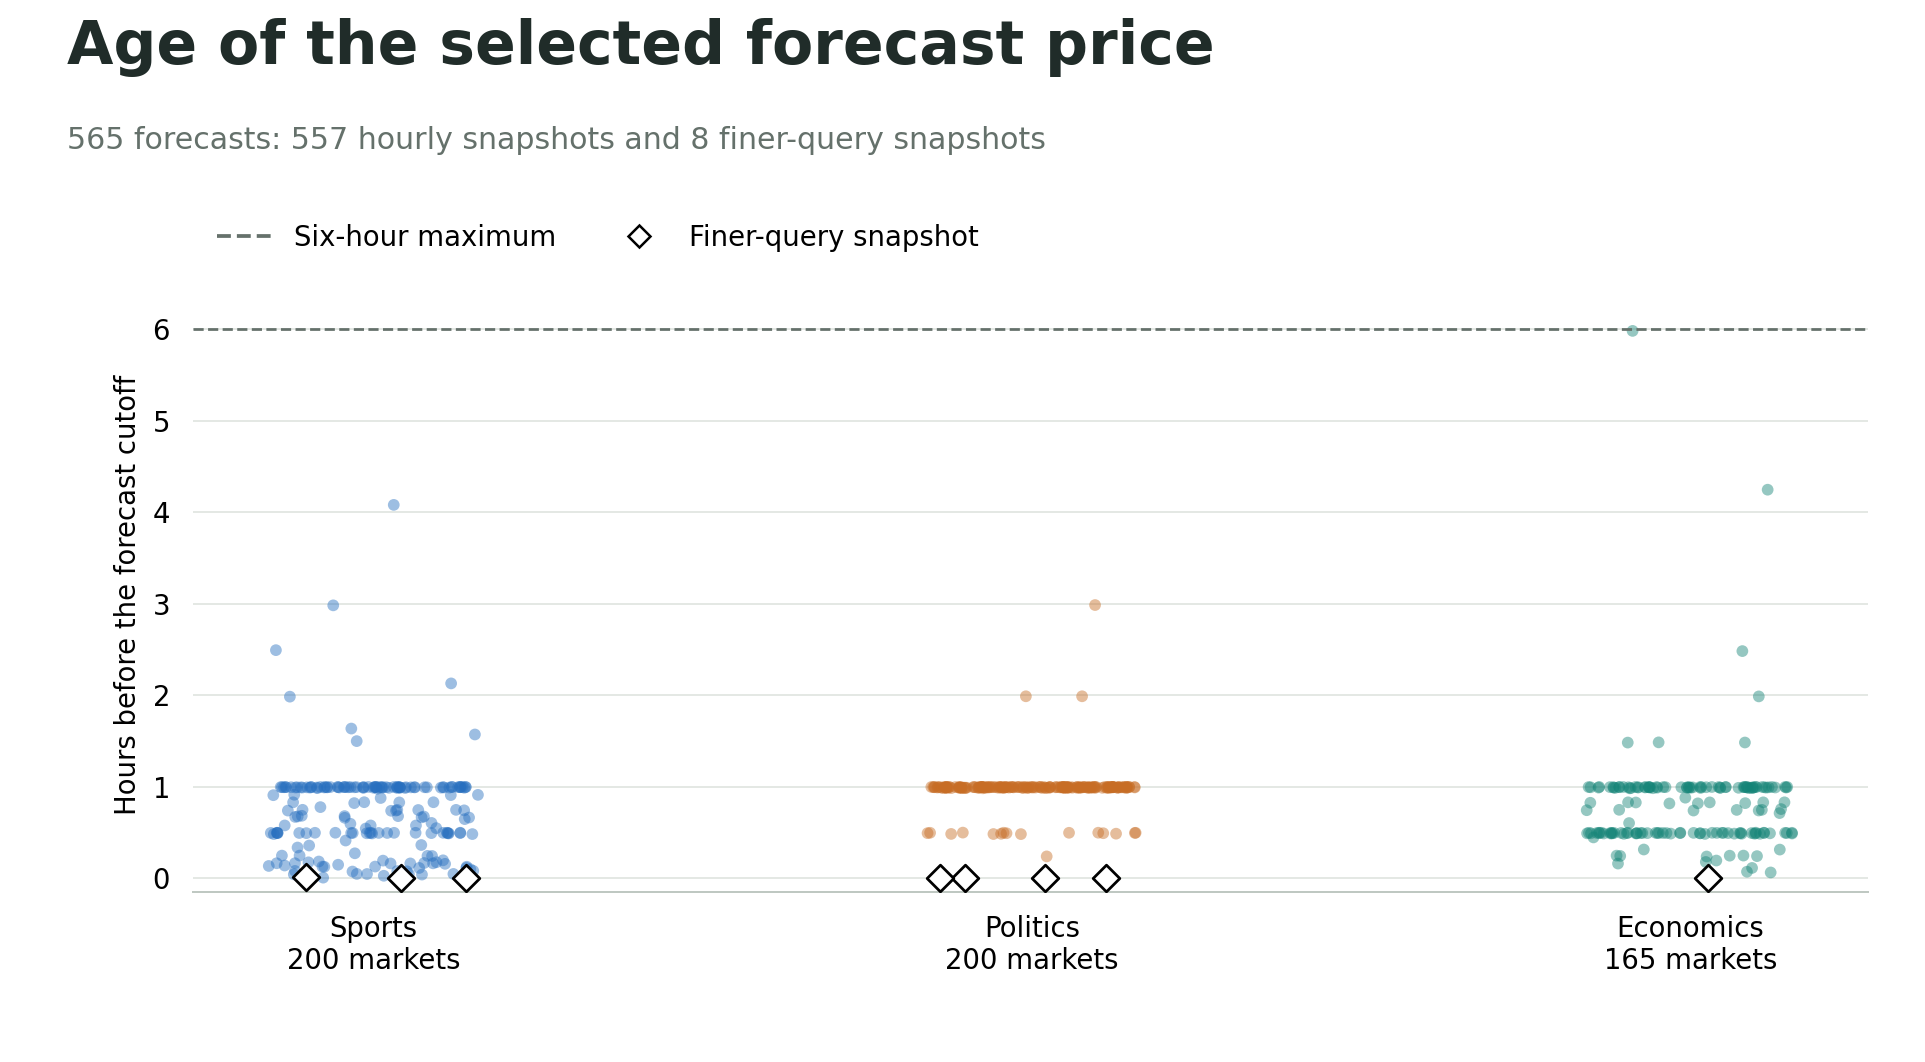

In [13]:
# Website source figure 12: current final sample.
def render_website_figure_12():
    from pathlib import Path
    import hashlib, json
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter, MaxNLocator

    root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/eda_tables.py').exists())
    data = root / 'data/eda/20260916_v2'
    output = root / 'figures/eda_20260917_final_refresh'
    output.mkdir(parents=True, exist_ok=True)
    manifest = json.loads((data / 'manifest.json').read_text(encoding='utf-8'))
    input_hashes = {}
    def load_checked(name):
        digest = hashlib.sha256((data / name).read_bytes()).hexdigest()
        assert digest == manifest['output_sha256'][name]
        input_hashes[name] = digest
        return pd.read_parquet(data / name)
    markets = load_checked('markets.parquet')
    topics = ['Sports', 'Politics', 'Economics']
    colors = {'Sports': '#276FBF', 'Politics': '#C76D25', 'Economics': '#148477'}
    assert len(markets) == markets.market_id.nunique() == markets.event_family_id.nunique() == 565
    assert markets.groupby('topic').size().reindex(topics).tolist() == [200, 200, 165]
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11, 'svg.fonttype': 'none', 'text.parse_math': False})
    stem = '12_snapshot_freshness'
    # Verify age from the actual cutoff/observation timestamps.
    prices = load_checked('price_history.parquet')
    assert len(prices) == 75061
    chart = markets[['market_id', 'topic', 'forecast_cutoff_utc', 'forecast_observation_utc',
                     'forecast_age_seconds', 'forecast_price_source', 'forecast_probability']].copy()
    computed_age = (chart.forecast_cutoff_utc - chart.forecast_observation_utc).dt.total_seconds()
    assert np.array_equal(computed_age.to_numpy(), chart.forecast_age_seconds.to_numpy())
    assert computed_age.between(0, 6 * 3600).all()
    assert chart.forecast_probability.between(0, 1).all()
    assert set(chart.forecast_price_source) == {'hourly', 'one_minute_fallback'}
    finer = chart.forecast_price_source.eq('one_minute_fallback')
    assert int(finer.sum()) == 8 and int((~finer).sum()) == 557
    # Every selected hourly snapshot must occur in that market's saved price path.
    hourly_lookup = prices[['market_id', 'observation_time_utc', 'probability']].drop_duplicates()
    joined = chart[~finer].merge(hourly_lookup, left_on=['market_id', 'forecast_observation_utc'],
                                right_on=['market_id', 'observation_time_utc'], how='left', validate='one_to_one')
    assert len(joined) == 557 and joined.probability.notna().all()
    assert np.allclose(joined.forecast_probability, joined.probability, rtol=0, atol=1e-12)
    fig, ax = plt.subplots(figsize=(10.7, 5.9))
    fig.subplots_adjust(left=.10, right=.97, top=.72, bottom=.16)
    fig.text(.035, .94, 'Age of the selected forecast price', fontsize=24, weight='bold', color='#202C29')
    fig.text(.035, .86, '565 forecasts: 557 hourly snapshots and 8 finer-query snapshots', fontsize=12, color='#65716B')
    rng = np.random.default_rng(20260917)
    for pos, topic in enumerate(topics):
        subset = chart[chart.topic.eq(topic)]
        x = pos + rng.uniform(-.16, .16, len(subset))
        recovered = subset.forecast_price_source.eq('one_minute_fallback').to_numpy()
        age_hours = subset.forecast_age_seconds.to_numpy(dtype=float) / 3600
        ax.scatter(x[~recovered], age_hours[~recovered], s=22, alpha=.45, color=colors[topic], edgecolors='none')
        ax.scatter(x[recovered], age_hours[recovered], s=57, marker='D', facecolors='white',
                   edgecolors='black', linewidths=1.1, zorder=4)
    ax.axhline(6, color='#65716B', linestyle='--', linewidth=1.1)
    ax.set_xticks(range(3), [f'{t}\n{int(chart.topic.eq(t).sum())} markets' for t in topics])
    ax.set_ylabel('Hours before the forecast cutoff')
    ax.set_ylim(-.15, 6.35)
    ax.set_yticks(range(7))
    ax.legend(handles=[Line2D([], [], color='#65716B', linestyle='--', label='Six-hour maximum'),
                       Line2D([], [], color='black', marker='D', markerfacecolor='white', linestyle='none', label='Finer-query snapshot')],
              loc='lower left', bbox_to_anchor=(0, 1.035), ncol=2, frameon=False)
    ax.grid(axis='y', color='#E4E8E4', linewidth=.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, pad=9)
    for side in ['top', 'right', 'left']:
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color('#BFC8C2')
    title = 'Cutoff snapshot freshness'
    caption = (
        'All 565 selected forecast prices were observed at or before the forecast cutoff and no more than six hours earlier. '
        'Of these, 557 come from the hourly price histories and eight from finer-query recovery: three Sports, four Politics '
        'and one Economics market. Diamonds mark the finer snapshots, which remain separate from the hourly price-path table. '
        'Each point represents one market; horizontal spacing only separates overlapping points.'
    )
    alt = ('Topic-colored points show forecast-price ages for 200 Sports, 200 Politics and 165 Economics markets. '
           'Every observation is between 9 seconds and 5 hours 59 minutes 1 second before cutoff. '
           'Eight finer-query snapshots are marked with diamonds, and a dashed line marks the six-hour maximum.')
    extra = dict(hourly_snapshots=557, finer_snapshots=8, min_age_seconds=int(computed_age.min()), max_age_seconds=int(computed_age.max()),
                 finer_by_topic={t: int((finer & chart.topic.eq(t)).sum()) for t in topics}, hourly_path_matches=557)
    chart[finer].to_csv(output / '12_finer_snapshot_inputs.csv', index=False)
    fig.savefig(output / (stem + '.png'), dpi=180)
    fig.savefig(output / (stem + '.svg'))
    plt.close(fig)
    chart.to_csv(output / (stem + '.csv'), index=False)
    details = dict(title=title, caption=caption, alt=alt, data_version='20260916_v2', markets=565,
                   topic_counts={'Sports': 200, 'Politics': 200, 'Economics': 165}, input_sha256=input_hashes,
                   checks_passed=True, **extra)
    (output / (stem + '_metadata.json')).write_text(json.dumps(details, indent=2) + '\n', encoding='utf-8')
    print(chart.to_string(index=False) if len(chart) < 30 else json.dumps(extra, indent=2))

with plt.rc_context(plt.rcParamsDefault):
    render_website_figure_12()

from IPython.display import Image, display
import shutil
figure_output = ROOT / 'figures/eda_20260917_final_refresh'
figure_details = json.loads((figure_output / '12_snapshot_freshness_metadata.json').read_text(encoding='utf-8'))
for extension in ['png', 'svg']:
    shutil.copy2(figure_output / ('12_snapshot_freshness.' + extension), FIGURES / ('12_snapshot_freshness.' + extension))
shutil.copy2(figure_output / '12_snapshot_freshness.csv', FIGURES / 'chart_data/12_snapshot_freshness.csv')
visuals.append(dict(id='12_snapshot_freshness', title=figure_details['title'], caption=figure_details['caption'],
                    source='Complete calculation code in this notebook cell', footer='', png='12_snapshot_freshness.png',
                    svg='12_snapshot_freshness.svg', data='chart_data/12_snapshot_freshness.csv'))
display(Image(filename=str(figure_output / '12_snapshot_freshness.png')))


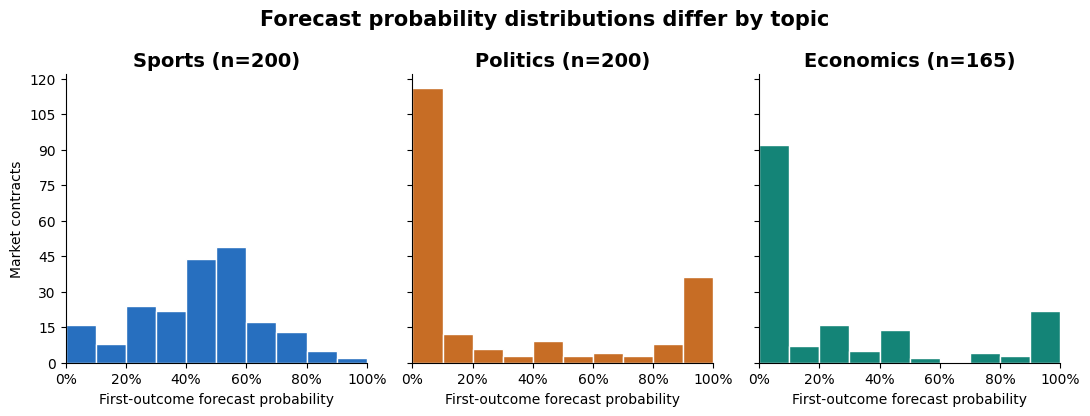

In [14]:
chart=markets[['market_id','topic','forecast_probability','outcome_0_result']]
fig,axes=plt.subplots(1,3,figsize=(11,4.2),sharex=True,sharey=True)
for ax,topic in zip(axes,TOPICS):
    subset=chart[chart.topic==topic];ax.hist(subset.forecast_probability.to_numpy(dtype=float),bins=np.linspace(0,1,11),color=COLORS[topic],edgecolor='white')
    ax.set(title=f'{topic} (n={len(subset)})',xlabel='First-outcome forecast probability',xlim=(0,1));ax.xaxis.set_major_formatter(PercentFormatter(1));ax.yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].set_ylabel('Market contracts');fig.suptitle('Forecast probability distributions differ by topic',weight='bold',fontsize=15)
save(fig,'13_forecast_distributions','Forecast probability distributions',
    'The contract-level probability distribution depends on the kinds of propositions sampled, including candidate fields and economic ranges. All plots refer to outcome index 0, which can be a named competitor rather than a Yes label.',
    chart,'markets.forecast_probability, outcome_0_result, topic',
    'Each market contributes once; different event structures and base rates limit direct topic comparisons.')

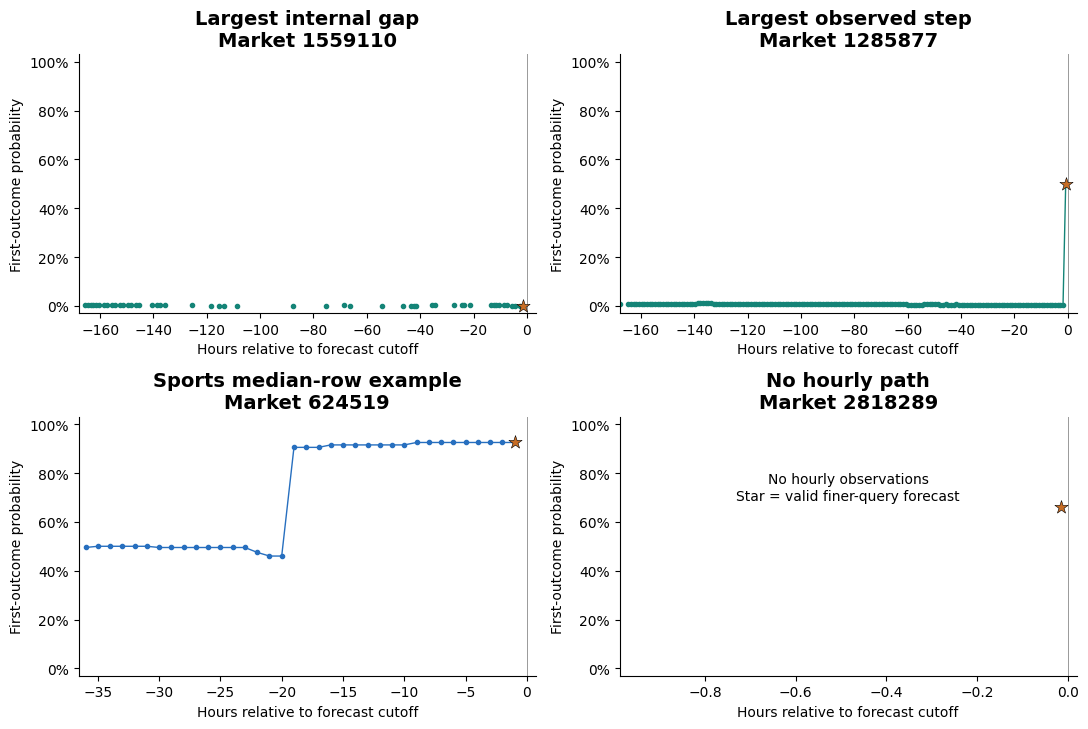

In [15]:
gap_id=markets.sort_values(['max_price_gap_hours','market_id'],ascending=[False,True]).iloc[0].market_id
step_id=markets.sort_values(['max_observed_price_step_pp','market_id'],ascending=[False,True]).iloc[0].market_id
sports=markets[markets.topic=='Sports'].copy();median_count=float(sports.trade_row_count.median())
sports['distance_to_median']=(sports.trade_row_count-median_count).abs()
typical_id=sports.sort_values(['distance_to_median','market_id']).iloc[0].market_id
selected=[('Largest internal gap',gap_id),('Largest observed step',step_id),('Sports median-row example',typical_id),('No hourly path','2818289')]
fig,axes=plt.subplots(2,2,figsize=(11,7.4));sources=[]
for ax,(label,mid) in zip(axes.flat,selected):
    market=markets[markets.market_id==mid].iloc[0];series=prices[prices.market_id==mid].copy()
    x=-series.hours_before_cutoff.to_numpy(dtype=float);y=series.probability.to_numpy(dtype=float)
    if len(series):
        line_x=[];line_y=[]
        for xx,yy,gap in zip(x,y,series.gap_over_90_minutes.fillna(False)):
            if gap:line_x.append(np.nan);line_y.append(np.nan)
            line_x.append(xx);line_y.append(yy)
        ax.plot(line_x,line_y,color=COLORS[market.topic],lw=1);ax.scatter(x,y,s=9,color=COLORS[market.topic])
    ax.scatter(-float(market.forecast_age_seconds)/3600,float(market.forecast_probability),marker='*',s=100,color='#C76D25',edgecolor='black',lw=.4,zorder=4)
    ax.set(title=f'{label}\nMarket {mid}',xlabel='Hours relative to forecast cutoff',ylabel='First-outcome probability',ylim=(-.03,1.03),xlim=(-float(market.window_hours),.02*float(market.window_hours)))
    ax.yaxis.set_major_formatter(PercentFormatter(1));ax.axvline(0,color='#999999',lw=.7)
    if series.empty:ax.text(.5,.68,'No hourly observations\nStar = valid finer-query forecast',transform=ax.transAxes,ha='center',fontsize=10)
    sources.extend(dict(market_id=mid,selection_rule=label,question=market.question,point_role='hourly_observation',hours_relative_cutoff=float(xx),probability=float(yy),source='hourly') for xx,yy in zip(x,y))
    sources.append(dict(market_id=mid,selection_rule=label,question=market.question,point_role='selected_forecast',hours_relative_cutoff=-float(market.forecast_age_seconds)/3600,probability=float(market.forecast_probability),source=market.forecast_price_source))
save(fig,'14_price_path_examples','Illustrative price paths and missingness',
    'Examples are selected by documented coverage rules: largest internal gap, largest observed step, a Sports market nearest the median row count, and the empty hourly series. Lines break across gaps longer than 90 minutes, and stars identify the selected cutoff forecasts.',
    pd.DataFrame(sources),'price_history observations joined to markets; deterministic selection rules in this cell',
    'The x-axis ends at the forecast cutoff, 24 hours before the event boundary. Extreme examples are illustrative, not representative; finer recovery is never appended to hourly paths.')

## 5. Preliminary forecast descriptions

These are contract-weighted descriptions of the retained cohort, with one contract per event family. Distinct families can still share calendar shocks and topic effects; no independent-observation confidence intervals are implied. Different topics contain different proposition structures and outcome frequencies.

For orientation only, the Brier score is the mean squared probability error, `(p - outcome)^2`; smaller is better. Its level across topics also depends on the difficulty and base rates of the sampled propositions. Establishing forecast skill needs suitable benchmarks and a later, family-aware evaluation design.

,markets,mean_probability,outcome_frequency,descriptive_brier
topic,,,,
Sports,200,0.442785,0.4,0.188755
Politics,200,0.293807,0.29,0.062693
Economics,165,0.257561,0.218182,0.06166


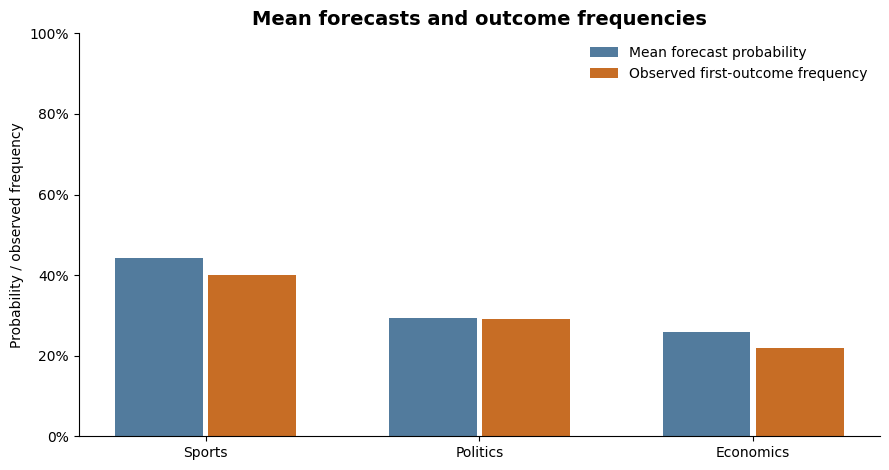

In [16]:
description=markets[['market_id','topic','forecast_probability','outcome_0_result']].copy()
description['squared_probability_error']=(description.forecast_probability-description.outcome_0_result)**2
summary=description.groupby('topic').agg(markets=('market_id','size'),mean_probability=('forecast_probability','mean'),outcome_frequency=('outcome_0_result','mean'),descriptive_brier=('squared_probability_error','mean')).reindex(TOPICS)
display(summary)
summary.to_csv(FIGURES/'chart_data/topic_forecast_descriptives.csv')
fig,ax=plt.subplots(figsize=(9,4.8));x=np.arange(3)
ax.bar(x-.17,summary.mean_probability.to_numpy(dtype=float),width=.32,label='Mean forecast probability',color='#527B9D')
ax.bar(x+.17,summary.outcome_frequency.to_numpy(dtype=float),width=.32,label='Observed first-outcome frequency',color='#C76D25')
ax.set_xticks(x,TOPICS);ax.set(title='Mean forecasts and outcome frequencies',ylabel='Probability / observed frequency',ylim=(0,1))
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(frameon=False)
save(fig,'15_forecast_outcome_averages','Preliminary forecast and outcome averages',
    'Mean forecast probabilities and observed outcome frequencies summarize each topic’s sampled propositions. Agreement in these two averages alone would not establish calibration within probability ranges or comparative crowd wisdom.',
    summary.reset_index(),'markets.forecast_probability, outcome_0_result, topic',
    f'Descriptive only: {len(markets)} contracts in {markets.event_family_id.nunique()} event families; no causal claim, benchmark comparison or independent-observation uncertainty estimate.')

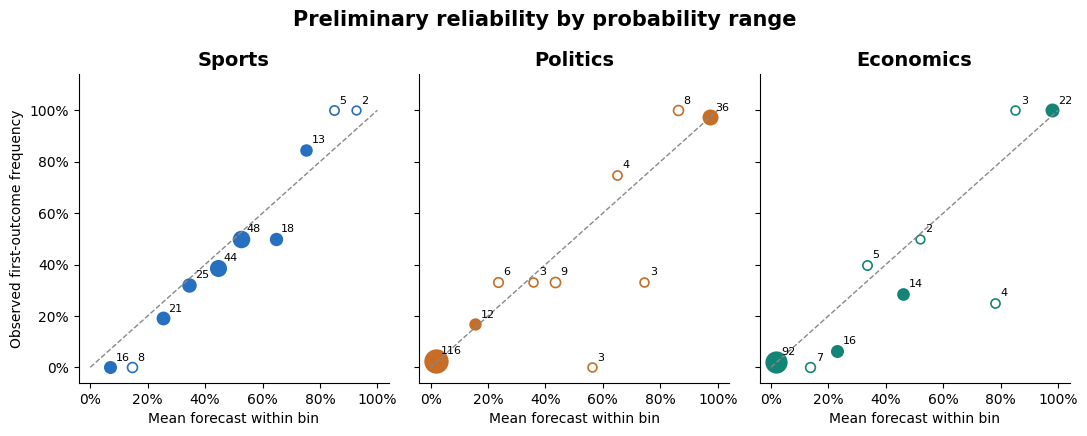

In [17]:
description['probability_bin']=np.minimum((description.forecast_probability.astype(float)*10).astype(int),9)
bins=description.groupby(['topic','probability_bin']).agg(n=('market_id','size'),mean_probability=('forecast_probability','mean'),outcome_frequency=('outcome_0_result','mean')).reset_index()
fig,axes=plt.subplots(1,3,figsize=(11,4.4),sharex=True,sharey=True)
for ax,topic in zip(axes,TOPICS):
    subset=bins[bins.topic==topic];ax.plot([0,1],[0,1],ls='--',color='#888888',lw=1)
    for row in subset.itertuples():
        ax.scatter(float(row.mean_probability),float(row.outcome_frequency),s=35+float(row.n)*2,facecolor=COLORS[topic] if row.n>=10 else 'white',edgecolor=COLORS[topic],lw=1.2)
        ax.annotate(str(int(row.n)),(float(row.mean_probability),float(row.outcome_frequency)),xytext=(4,5),textcoords='offset points',fontsize=8)
    ax.set(title=topic,xlabel='Mean forecast within bin',xlim=(-.04,1.04),ylim=(-.06,1.14));ax.xaxis.set_major_formatter(PercentFormatter(1));ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_ylabel('Observed first-outcome frequency');fig.suptitle('Preliminary reliability by probability range',weight='bold',fontsize=15)
save(fig,'16_preliminary_reliability','Preliminary reliability plot',
    'Markets are grouped into fixed ten-percentage-point forecast bins, with point labels showing the number of contracts. Sparse bins are hollow and the plot shows no confidence intervals because calendar dependence and the sampling design require a separate uncertainty analysis.',
    bins,'markets.forecast_probability, outcome_0_result, topic; fixed bins [0,.1),...,[.9,1]',
    'Point labels = contracts; hollow points have fewer than 10 contracts. Diagonal = equal probability/frequency, not a fitted line. This is exploratory evidence, not a calibration verdict.')

## 6. Review a raw row beside its transformed counterpart

The canonical outcome name comes from the validated token ID/index. The original returned text is retained. These examples show presentation changes without altering the trade price, size or timestamp.

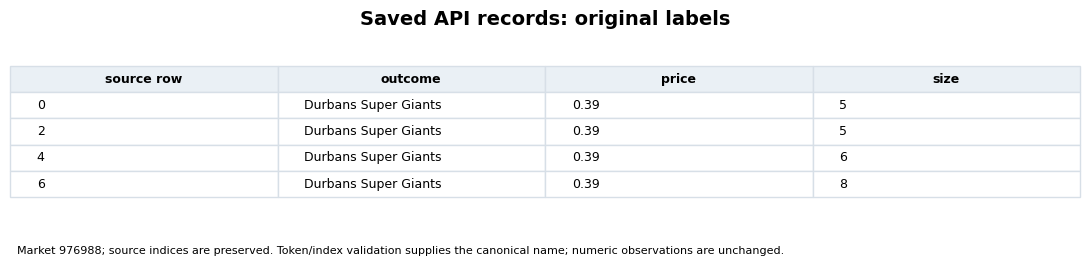

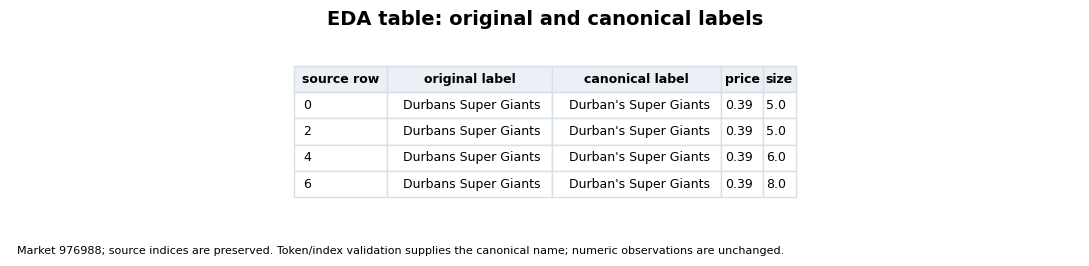

In [18]:
import gzip
trades=load_table('trades',columns=['market_id','source_row_index','outcome_label_raw','outcome_label','price','size','outcome_label_changed','duplicate_occurrence','source_file'])
example=trades[(trades.market_id=='976988') & trades.outcome_label_changed].sort_values('source_row_index').head(4)
raw=json.loads(gzip.decompress((ROOT/example.iloc[0].source_file).read_bytes()))
raw_frame=pd.DataFrame([{'source row':int(i),'outcome':raw[int(i)]['outcome'],'price':raw[int(i)]['price'],'size':raw[int(i)]['size']} for i in example.source_row_index])
clean_frame=example[['source_row_index','outcome_label_raw','outcome_label','price','size']].copy()
clean_frame.columns=['source row','original label','canonical label','price','size']
for stem,title,frame in [('raw_trade_example','Saved API records: original labels',raw_frame),('clean_trade_example','EDA table: original and canonical labels',clean_frame)]:
    fig,ax=plt.subplots(figsize=(11,2.7));ax.axis('off');ax.set_title(title,pad=15)
    table=ax.table(cellText=frame.astype(str).values,colLabels=frame.columns,loc='center',cellLoc='left')
    table.auto_set_font_size(False);table.set_fontsize(9);table.scale(1,1.9)
    if len(frame.columns)==5:table.auto_set_column_width(col=range(5))
    for (r,c),cell in table.get_celld().items():
        cell.set_edgecolor('#D7DFE7')
        if r==0:cell.set_facecolor('#EAF0F5');cell.set_text_props(weight='bold')
    fig.text(.02,.04,'Market 976988; source indices are preserved. Token/index validation supplies the canonical name; numeric observations are unchanged.',fontsize=8)
    fig.tight_layout(rect=(0,.12,1,1));fig.savefig(FIGURES/f'{stem}.png',dpi=180);fig.savefig(FIGURES/f'{stem}.svg');display(fig);plt.close(fig)
del trades

## 7. What this EDA supports and what remains open

- The three typed tables now support descriptive forecast, activity, participation and concentration analysis with explicit coverage and provenance.
- No-returned-trade windows, short histories, unresolved historical option counts and price gaps remain visible; no imputation, arbitrary row deletion or model scaling has been performed.
- Exact exchange turnover, maker/taker aggressiveness, wallet experience and wallet accuracy require further definitions or data. BUY/SELL and these bounded histories do not settle them.
- The reliability plots are candidate descriptive visuals. Formal calibration/skill conclusions, causal interpretations and later-market modeling remain separate work.

The exports below contain the ten website figures, additional current-sample analyses, chart data and captions. All are regenerated from the fixed input tables when the notebook runs.

In [19]:
(FIGURES/'visuals.json').write_text(json.dumps(visuals,indent=2,ensure_ascii=False)+'\n',encoding='utf-8')
lines=['# EDA figures for the final 565-market sample','',
       f'{len(visuals)} current-sample figures, including the ten website charts, plus raw/clean examples. Each plot has PNG and SVG exports and its plotted data.',
       '', '![Contact sheet](contact_sheet.png)', '',
       'Figures 15–16 are preliminary forecast descriptions. No model or formal crowd-wisdom conclusion is presented.']
for item in visuals:
    lines += ['',f"## {item['id']}: {item['title']}",'',item['caption'],'',
              f"[PNG]({item['png']}) | [SVG]({item['svg']}) | [Plotted data]({item['data']})",'',
              f"Source: {item['source']}", '', f"Interpretation note: {item['footer']}"]
lines+=['','## Raw and cleaned examples','','[Raw rows](raw_trade_example.png) | [Cleaned rows](clean_trade_example.png)',
        '', 'The cleaned table preserves the original outcome text and adds the token-mapped canonical label. Prices, sizes and source row indices are unchanged.']
(FIGURES/'README.md').write_text('\n'.join(lines)+'\n',encoding='utf-8')
fig,axes=plt.subplots(4,4,figsize=(22,15.5))
for ax,item in zip(axes.flat,visuals):
    ax.imshow(plt.imread(FIGURES/item['png']));ax.axis('off')
fig.suptitle(f'{len(markets)}-market EDA',fontsize=20,weight='bold');fig.tight_layout(rect=(0,0,1,.97))
fig.savefig(FIGURES/'contact_sheet.png',dpi=150);plt.close(fig)
# Larger review sheets allow inspection of all charts, four at a time.
for start in range(0,len(visuals),4):
    fig,axes=plt.subplots(2,2,figsize=(16,11))
    for ax,item in zip(axes.flat,visuals[start:start+4]):ax.imshow(plt.imread(FIGURES/item['png']));ax.axis('off')
    fig.tight_layout();fig.savefig(FIGURES/f'review_sheet_{start//4+1}.png',dpi=150);plt.close(fig)
analysis=dict(markets=len(markets),event_families=int(markets.event_family_id.nunique()),
    total_gross_account_activity=float(markets.gross_account_activity.sum()),
    total_sensitivity_account_activity=float(markets.sensitivity_account_activity.sum()),
    top_three_activity_share=float(markets.gross_account_activity.nlargest(3).sum()/markets.gross_account_activity.sum()),
    descriptive_topic_forecasts=summary.reset_index().to_dict(orient='records'),
    visuals=len(visuals),source_table_manifest_sha256=hashlib.sha256((DATA/'manifest.json').read_bytes()).hexdigest(),
    limitations=['Account activity is not reconciled exchange turnover.','Calibration figures are descriptive; unique families do not establish statistical independence.',
                 'Zero-trade windows do not mean no lifetime trading.','No model-specific normalization or model training.'])
(FIGURES/'eda_summary.json').write_text(json.dumps(analysis,indent=2)+'\n',encoding='utf-8')
print(f"Created {len(visuals)} current-sample figures, chart-data exports, captions and raw/clean examples.")

Created 16 current-sample figures, chart-data exports, captions and raw/clean examples.
